<img src="https://github.com/hernancontigiani/ceia_memorias_especializacion/raw/master/Figures/logoFIUBA.jpg" width="500" align="center">

# Actividad 3 - Reducción de dimensionalidad y clustering
### Análisis de datos II - 4B2026

### Alumno: Fontanari Federico

**Dataset:** [Human Activity Recognition Using Smartphones](https://archive.ics.uci.edu/dataset/240/human+activity+recognition+using+smartphones)

La idea de este trabajo es explorar la estructura del dataset sin usar las etiquetas. Primero reducimos la dimensionalidad con PCA, después probamos distintos algoritmos de clustering y elegimos uno, y recién al final miramos la actividad real para interpretar los grupos. Como complemento, usamos UMAP para visualizar los datos en 2 dimensiones.

In [1]:
!pip install umap-learn -q

In [2]:
%matplotlib inline
import os
import glob
import zipfile
import urllib.request
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import to_hex

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, HDBSCAN
from sklearn.metrics import silhouette_score, silhouette_samples, adjusted_rand_score, adjusted_mutual_info_score
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster, set_link_color_palette
from scipy.optimize import linear_sum_assignment

RANDOM_STATE = 14

ORDEN_ACTIVIDADES = ["WALKING", "WALKING_UPSTAIRS", "WALKING_DOWNSTAIRS", "SITTING", "STANDING", "LAYING"]
COLORES_ACTIVIDADES = dict(zip(ORDEN_ACTIVIDADES, sns.color_palette("tab10", 6)))
COLORES_CLUSTERS = ["dimgray", "goldenrod", "darkcyan", "crimson", "mediumpurple", "sienna", "olivedrab",
                    "steelblue", "orchid", "darkorange", "navy", "yellowgreen"]

## 1. Carga y descripción del dataset

In [3]:
URL_DATASET = "https://archive.ics.uci.edu/static/public/240/human+activity+recognition+using+smartphones.zip"
ARCHIVO_ZIP = "human+activity+recognition+using+smartphones.zip"
CARPETA = "har_dataset"

# Descarga y descompresión (solo la primera vez)
if not os.path.exists(ARCHIVO_ZIP):
    urllib.request.urlretrieve(URL_DATASET, ARCHIVO_ZIP)

with zipfile.ZipFile(ARCHIVO_ZIP) as z:
    z.extractall(CARPETA)

# El zip trae adentro otro zip con los datos: lo descomprimimos también
for zip_interno in glob.glob(os.path.join(CARPETA, "*.zip")):
    with zipfile.ZipFile(zip_interno) as z:
        z.extractall(CARPETA)

base = os.path.dirname(glob.glob(os.path.join(CARPETA, "**", "features.txt"), recursive=True)[0])

# Nombres de las 561 variables. Algunos se repiten en features.txt,
# así que a las repeticiones les agregamos un sufijo (.1, .2) para que sean únicos
nombres = pd.read_csv(os.path.join(base, "features.txt"), sep=r"\s+", header=None)[1]
repeticion = nombres.groupby(nombres).cumcount()
nombres = np.where(repeticion == 0, nombres, nombres + "." + repeticion.astype(str))

actividades = pd.read_csv(os.path.join(base, "activity_labels.txt"), sep=r"\s+", header=None, index_col=0)[1]


def cargar_particion(particion):
    """Arma el DataFrame de una partición (train o test): 561 variables + persona + actividad."""
    carpeta = os.path.join(base, particion)
    variables = pd.read_csv(os.path.join(carpeta, f"X_{particion}.txt"), sep=r"\s+", header=None, names=nombres)
    persona = pd.read_csv(os.path.join(carpeta, f"subject_{particion}.txt"), header=None)[0]
    codigo_actividad = pd.read_csv(os.path.join(carpeta, f"y_{particion}.txt"), header=None)[0]
    return variables.assign(subject=persona, Activity=codigo_actividad.map(actividades))


train = cargar_particion("train")
test = cargar_particion("test")

# Para un análisis no supervisado no necesitamos la división train/test: unimos todo
df = pd.concat([train, test], ignore_index=True)
print(f"train: {train.shape} | test: {test.shape} | total: {df.shape}")
df.head(5)

train: (7352, 563) | test: (2947, 563) | total: (10299, 563)


,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",subject,Activity
0,0.288585,-0.020294,-0.132905,-0.995279,-0.983111,-0.913526,-0.995112,-0.983185,-0.923527,-0.934724,...,-0.710304,-0.112754,0.030400,-0.464761,-0.018446,-0.841247,0.179941,-0.058627,1,STANDING
1,0.278419,-0.016411,-0.123520,-0.998245,-0.975300,-0.960322,-0.998807,-0.974914,-0.957686,-0.943068,...,-0.861499,0.053477,-0.007435,-0.732626,0.703511,-0.844788,0.180289,-0.054317,1,STANDING
2,0.279653,-0.019467,-0.113462,-0.995380,-0.967187,-0.978944,-0.996520,-0.963668,-0.977469,-0.938692,...,-0.760104,-0.118559,0.177899,0.100699,0.808529,-0.848933,0.180637,-0.049118,1,STANDING
3,0.279174,-0.026201,-0.123283,-0.996091,-0.983403,-0.990675,-0.997099,-0.982750,-0.989302,-0.938692,...,-0.482845,-0.036788,-0.012892,0.640011,-0.485366,-0.848649,0.181935,-0.047663,1,STANDING
4,0.276629,-0.016570,-0.115362,-0.998139,-0.980817,-0.990482,-0.998321,-0.979672,-0.990441,-0.942469,...,-0.699205,0.123320,0.122542,0.693578,-0.615971,-0.847865,0.185151,-0.043892,1,STANDING


In [4]:
df["Activity"].value_counts(dropna=False)

,count
Activity,
LAYING,1944
STANDING,1906
SITTING,1777
WALKING,1722
WALKING_UPSTAIRS,1544
WALKING_DOWNSTAIRS,1406


**¿Qué representa cada observación?** Un grupo de 30 personas hizo 6 actividades cotidianas con un smartphone encima. Tanto el acelerómetro como el giroscopio del teléfono registraron el movimiento. Esas señales se cortaron en ventanas de 2,56 segundos. Cada fila del dataset es una de esas ventanas, descripta por 561 variables calculadas a partir de las señales (medias, desvíos, máximos, energía, frecuencias, ángulos, etc.).

El dataset viene repartido en varios archivos de texto: las variables (`X_train.txt`, `X_test.txt`), sus nombres (`features.txt`), la persona (`subject_*.txt`) y el código de la actividad (`y_*.txt`, con los nombres en `activity_labels.txt`). Los juntamos en un único DataFrame. La división en train y test no la necesitamos porque no vamos a entrenar un modelo supervisado.

Además de las 561 variables quedan dos columnas que no usamos para la reducción de dimensionalidad ni para el clustering:
- `subject`: la persona que hizo la actividad.
- `Activity`: la actividad realizada. Es la etiqueta del problema, y la dejamos solo para la interpretación.

In [5]:
X = df.drop(columns=["subject", "Activity"])
actividad = df["Activity"]
sujeto = df["subject"]

print("Tipos de datos de las variables:", X.dtypes.value_counts().to_dict())
print(f"Valores faltantes: {df.isna().sum().sum()}")
print(f"Filas duplicadas: {X.duplicated().sum()}")
print(f"Rango de valores: [{X.min().min()}, {X.max().max()}]")
print(f"Personas: {sujeto.nunique()}")

Tipos de datos de las variables: {dtype('float64'): 561}
Valores faltantes: 0
Filas duplicadas: 0
Rango de valores: [-1.0, 1.0]
Personas: 30


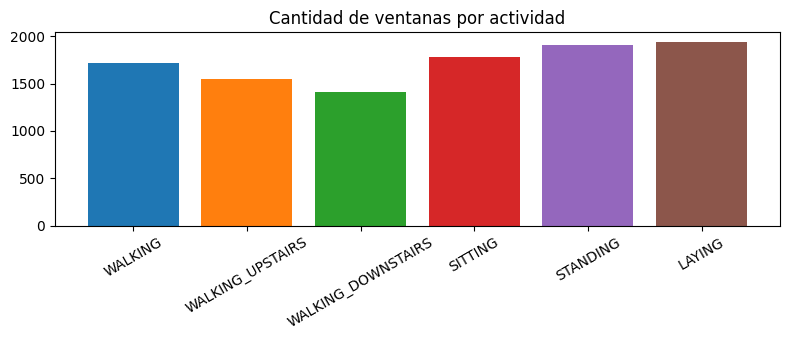

In [6]:
fig, ax = plt.subplots(figsize=(8, 3.5))
conteo = actividad.value_counts().reindex(ORDEN_ACTIVIDADES)
ax.bar(conteo.index, conteo.values, color=[COLORES_ACTIVIDADES[a] for a in conteo.index])
ax.set_title("Cantidad de ventanas por actividad")
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

Los nombres de las variables están codificados. En la documentación del dataset (`features_info.txt`, que viene en el zip) se explica qué significa cada parte:
- `t` o `f` al principio: la variable se calculó sobre la señal en el tiempo o sobre su transformada de Fourier (frecuencia).
- `Body` o `Gravity`: la aceleración se separó en una parte que viene del movimiento del cuerpo y otra que viene de la gravedad. Como la gravedad siempre apunta hacia abajo, esta segunda parte nos dice, básicamente, cómo está orientado el teléfono.
- `Acc` o `Gyro`: acelerómetro (aceleración lineal) o giroscopio (velocidad de rotación).
- `Jerk`: la derivada de la aceleración, es decir, qué tan brusco es el movimiento. `Mag`: la magnitud del vector, que combina los 3 ejes.
- `angle(...)`: ángulos entre vectores, por ejemplo entre cada eje del teléfono y la gravedad.

Con esto podemos agrupar las variables por familia:

In [7]:
familias = pd.DataFrame({
    "dominio": np.where(X.columns.str.startswith("f"), "frecuencia (f)",
                        np.where(X.columns.str.startswith("angle"), "ángulo", "tiempo (t)")),
    "sensor": np.where(X.columns.str.contains("Gyro"), "giroscopio", "acelerómetro"),
    "componente": np.where(X.columns.str.contains("Gravity") | X.columns.str.startswith("angle"),
                           "gravedad / orientación", "movimiento del cuerpo"),
})
print(familias.value_counts().to_frame("variables"))

                                                    variables
dominio        sensor       componente                       
frecuencia (f) acelerómetro movimiento del cuerpo         184
tiempo (t)     giroscopio   movimiento del cuerpo         106
               acelerómetro movimiento del cuerpo         106
frecuencia (f) giroscopio   movimiento del cuerpo         105
tiempo (t)     acelerómetro gravedad / orientación         53
ángulo         acelerómetro gravedad / orientación          5
               giroscopio   gravedad / orientación          2


La gran mayoría de las variables describe el movimiento del cuerpo: las de gravedad y orientación son solo 60 de 561

**Preprocesamiento.** No hay valores faltantes ni duplicados, y todas las variables son numéricas, así que no hay que imputar ni codificar nada. Las variables ya vienen normalizadas entre -1 y 1, pero eso no quiere decir que tengan la misma varianza. Algunas recorren todo el rango y otras casi no se mueven. PCA busca las direcciones de máxima varianza, así que si no estandarizamos, las variables que más varían terminarían dominando el resultado. Por eso aplicamos `StandardScaler` (media 0 y desvío 1 en cada variable), como en la notebook de reducción de dimensionalidad del curso.

In [8]:
X_std = StandardScaler().fit_transform(X)

## 2. Hipótesis

Antes de hacer cualquier análisis, anotamos qué esperamos encontrar a partir de cómo se generaron los datos:

1. **Movimiento vs. reposo.** Caminar y subir o bajar escaleras generan aceleraciones y rotaciones mucho más grandes que estar sentado, parado o acostado. Creemos que esta va a ser la división más fuerte.
2. **Acostado debería diferenciarse del resto de las actividades en reposo**, porque el teléfono queda orientado de otra forma respecto de la gravedad.
3. **Sentado y parado van a ser difíciles de separar:** en los dos casos el cuerpo está quieto y el teléfono queda vertical.
4. **Las tres formas de caminar se van a mezclar**, y puede aparecer un efecto de la persona, porque cada uno camina a su manera.

## 3a. Reducción de dimensionalidad: PCA

Primero ajustamos PCA con todas las componentes para ver cómo se va acumulando la varianza explicada.

Componentes para explicar el 80% de la varianza: 27
Componentes para explicar el 85% de la varianza: 42
Componentes para explicar el 90% de la varianza: 65
Componentes para explicar el 95% de la varianza: 104

Varianza explicada por PC1: 50.7%


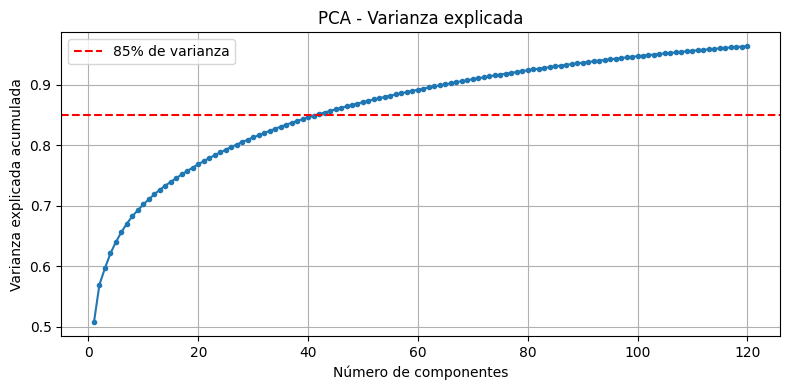

In [9]:
pca_completo = PCA(random_state=RANDOM_STATE).fit(X_std)

# varianza explicada por cada componente y acumulada
explained_var = pca_completo.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)

for umbral in [0.80, 0.85, 0.90, 0.95]:
    print(f"Componentes para explicar el {umbral:.0%} de la varianza: {np.argmax(cumulative_var >= umbral) + 1}")
print(f"\nVarianza explicada por PC1: {explained_var[0]:.1%}")

componentes = np.arange(1, 121)   # graficamos las primeras 120 componentes
plt.figure(figsize=(8, 4))
plt.plot(componentes, cumulative_var[:120], marker='o', markersize=3)
plt.xlabel('Número de componentes')
plt.ylabel('Varianza explicada acumulada')
plt.title('PCA - Varianza explicada')
plt.grid(True)
plt.axhline(y=0.85, color='red', linestyle='--', label='85% de varianza')
plt.tight_layout()
plt.legend()
plt.show()

La curva sube muy rápido al principio y después se aplana. La primera componente sola explica la mitad de la varianza (50,7%). Tiene sentido, porque muchas de las 561 variables son estadísticos distintos de la misma señal y están muy correlacionadas entre sí.

Seguimos el criterio del curso y nos quedamos con las componentes necesarias para explicar el 85% de la varianza. Así pasamos de 561 variables a 42, una representación mucho más manejable para el clustering.

In [10]:
pca = PCA(n_components=0.85, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_std)
print(f"Dimensiones: {X.shape[1]} -> {X_pca.shape[1]} (varianza explicada: {pca.explained_variance_ratio_.sum():.1%})")

Dimensiones: 561 -> 42 (varianza explicada: 85.1%)


**¿Qué representa la primera componente?** Para entenderla miramos qué variables tienen más peso. También graficamos los datos sobre las dos primeras componentes, primero sin etiquetas y después coloreados por actividad.

Variables (estandarizadas) con mayor peso en PC1, en valor absoluto:
fBodyAcc-sma()                0.0586
fBodyAccJerk-sma()            0.0586
fBodyGyro-sma()               0.0586
tBodyAccJerk-sma()            0.0585
tBodyAccJerkMag-mean()        0.0585
tBodyAccJerkMag-sma()         0.0585
fBodyBodyAccJerkMag-mean()    0.0581
fBodyBodyAccJerkMag-sma()     0.0581
tBodyAccJerkMag-mad()         0.0580
tBodyAccJerkMag-std()         0.0580


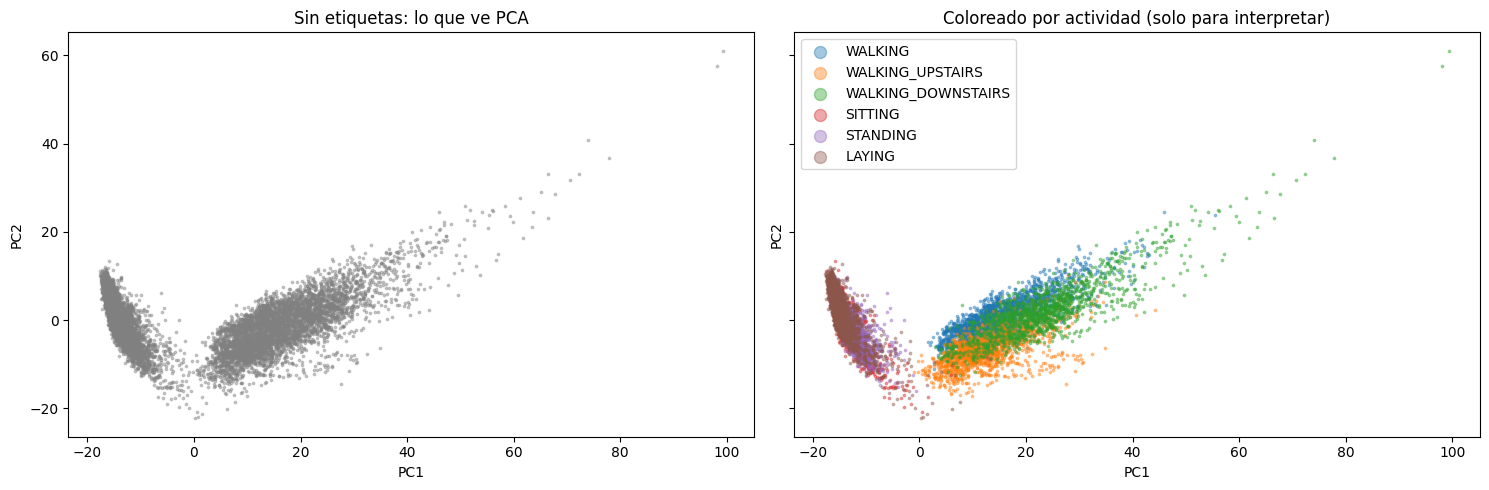

In [11]:
loadings_pc1 = pd.Series(pca.components_[0], index=X.columns)
print("Variables (estandarizadas) con mayor peso en PC1, en valor absoluto:")
print(loadings_pc1.abs().sort_values(ascending=False).head(10).round(4).to_string())

fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharex=True, sharey=True)

axes[0].scatter(X_pca[:, 0], X_pca[:, 1], s=3, alpha=0.4, color="gray")
axes[0].set_title("Sin etiquetas: lo que ve PCA")

for a in ORDEN_ACTIVIDADES:
    m = (actividad == a).values
    axes[1].scatter(X_pca[m, 0], X_pca[m, 1], s=3, alpha=0.4, color=COLORES_ACTIVIDADES[a], label=a)
axes[1].set_title("Coloreado por actividad (solo para interpretar)")
axes[1].legend(markerscale=5)

for ax in axes:
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
plt.tight_layout()
plt.show()

Las variables que más pesan en PC1 son todas medidas de energía o magnitud del movimiento (`sma` es la magnitud de la señal y `Jerk` mide qué tan brusca es). Además, los pesos son casi iguales entre sí. Esto muestra que PC1 no depende de unas pocas variables: resume muchas medidas de movimiento a la vez. Por eso, PC1 se puede leer como un eje de "cuánto se mueve la persona".

En el gráfico sin etiquetas ya se ven dos nubes bien separadas a lo largo de PC1. Cuando coloreamos por actividad:
- La nube de la izquierda son las tres actividades en reposo y la de la derecha, las tres en movimiento. Es la primera señal a favor de la hipótesis 1.
- Dentro del movimiento se insinúa un orden: subir escaleras queda más cerca del comienzo de PC1 y bajar escaleras se estira más hacia la derecha, hacia mayor intensidad.
- Dentro del reposo, las actividades se superponen. Acostado tiende a quedar en la parte de arriba de la nube, pero en estas dos componentes no se separa de sentado y parado.

Hay que tener en cuenta que acá vemos solo 2 de las 42 componentes (el 57% de la varianza). El clustering trabaja sobre las 42.

## 3b. Clustering

Probamos tres algoritmos sobre la representación de PCA, uno de cada familia que vimos en clase:
- **K-Means**, que agrupa alrededor de centroides y tiende a armar grupos esféricos y de tamaño parecido.
- **Clustering jerárquico**, que arranca con cada punto como un grupo y los va fusionando de a dos. Usamos el criterio de Ward, que en cada paso une los dos grupos que menos aumentan la varianza interna. El resultado es un dendrograma, que después se corta en la cantidad de grupos que queramos.
- **HDBSCAN**, basado en densidad: busca zonas densas, no hace falta indicarle cuántos grupos buscar y puede dejar puntos como ruido.

Para evaluarlos usamos las herramientas del curso, y ninguna usa la actividad:
- El índice de la silueta, que mide qué tan cerca está cada punto de su propio grupo comparado con el grupo vecino (va de -1 a 1, y cuanto más alto, mejor). Lo miramos promediado y también por cluster.
- La estabilidad por bootstrapping con el índice de Jaccard, para ver si los clusters se mantienen cuando reentrenamos con submuestras de los datos.
- ARI y AMI entre algoritmos, para ver cuánto coinciden los agrupamientos.

In [12]:
def ordenar_por_tamanio(etiquetas):
    """Renumera los clusters de mayor a menor tamaño (0 = el más grande). El ruido de HDBSCAN (-1) se mantiene."""
    etiquetas = pd.Series(etiquetas)
    orden = etiquetas[etiquetas != -1].value_counts().index
    mapeo = {viejo: nuevo for nuevo, viejo in enumerate(orden)}
    mapeo[-1] = -1
    return etiquetas.map(mapeo).values


def graficar_clusters(ax, etiquetas, titulo, coords=None, ejes=("PC1", "PC2")):
    """Grafica los datos coloreados por cluster (por defecto en PC1-PC2). El ruido (-1) se dibuja primero, en gris claro."""
    coords = X_pca if coords is None else coords
    ruido = etiquetas == -1
    if ruido.any():
        ax.scatter(coords[ruido, 0], coords[ruido, 1], s=3, alpha=0.3, color="lightgray", label=f"Ruido ({ruido.sum()})")
    for k in range(etiquetas.max() + 1):
        m = etiquetas == k
        ax.scatter(coords[m, 0], coords[m, 1], s=3, alpha=0.5, color=COLORES_CLUSTERS[k], label=f"Cluster {k} ({m.sum()})")
    ax.set_title(titulo)
    ax.set_xlabel(ejes[0])
    ax.set_ylabel(ejes[1])
    ax.legend(markerscale=5, fontsize=8)

### K-Means

In [13]:
silhouette_kmeans = {}
etiquetas_kmeans = {}

for i in range(2, 9):
    kmeans = KMeans(n_clusters=i, init="k-means++", random_state=RANDOM_STATE, n_init=10)
    etiquetas_kmeans[i] = ordenar_por_tamanio(kmeans.fit_predict(X_pca))

    silhouette_kmeans[i] = silhouette_score(X_pca, etiquetas_kmeans[i])
    print(f"{i} clusters: silhouette = {silhouette_kmeans[i]:.3f}")

2 clusters: silhouette = 0.461
3 clusters: silhouette = 0.378
4 clusters: silhouette = 0.199
5 clusters: silhouette = 0.176
6 clusters: silhouette = 0.162
7 clusters: silhouette = 0.129
8 clusters: silhouette = 0.120


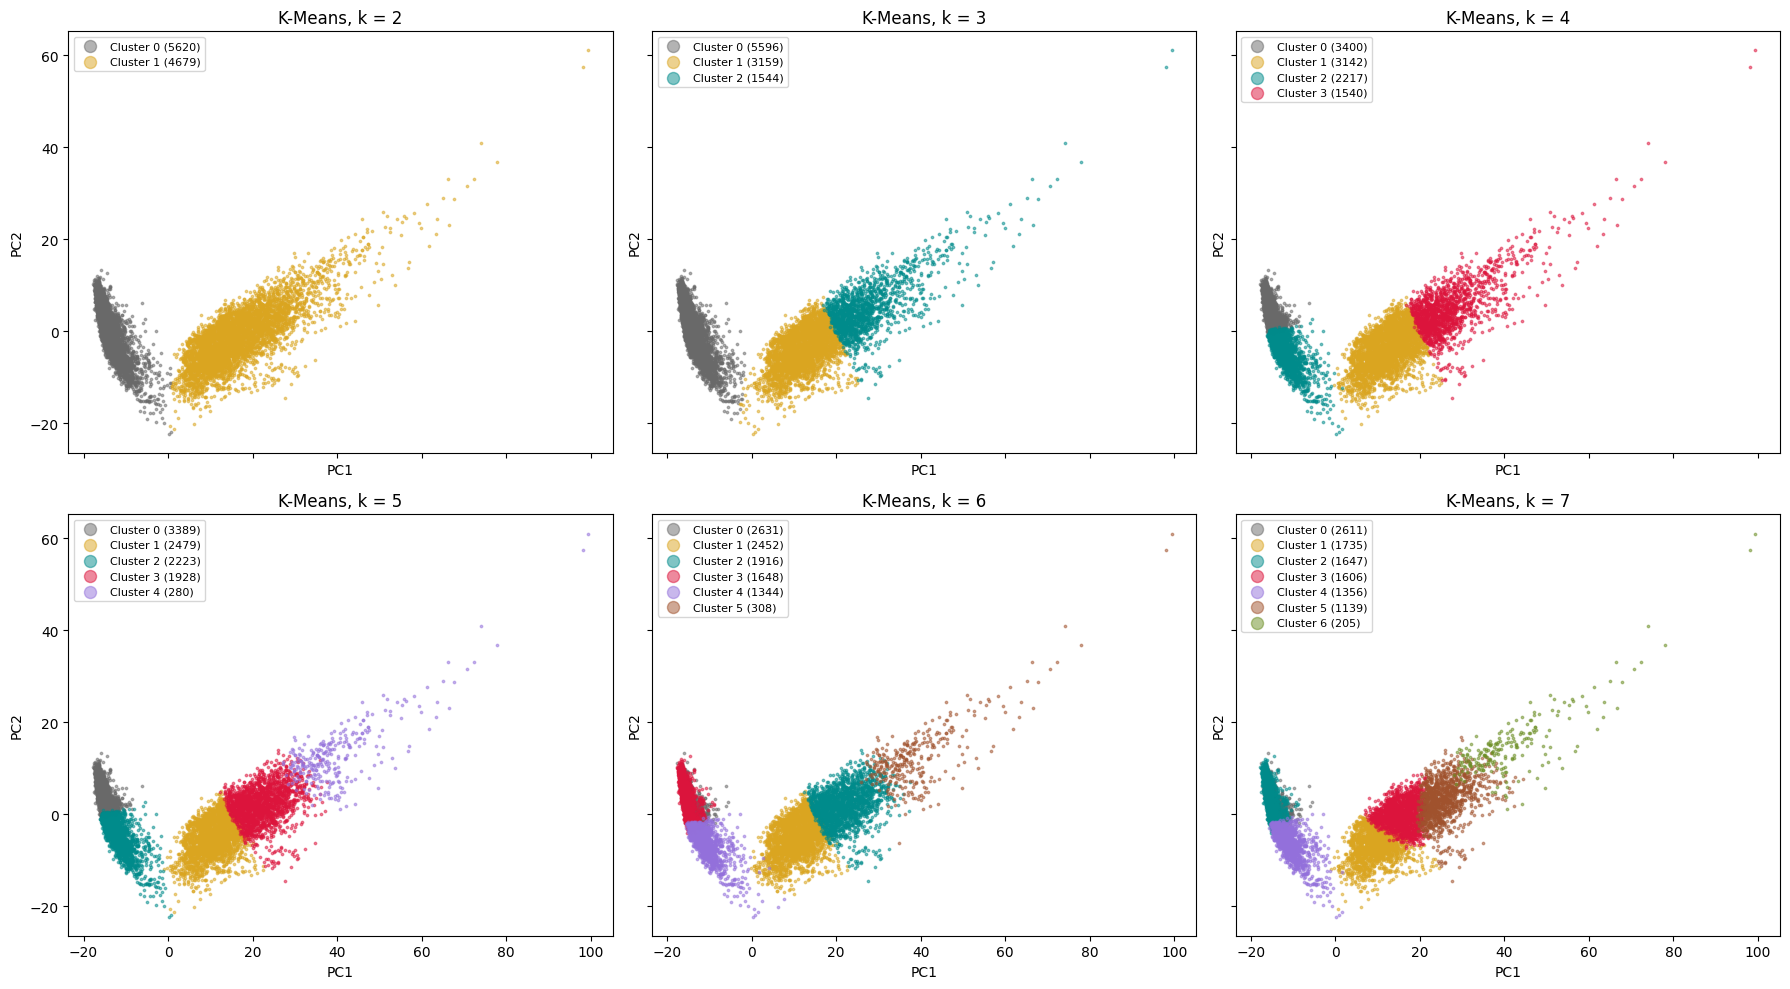

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharex=True, sharey=True)
for ax, k in zip(axes.flatten(), range(2, 8)):
    graficar_clusters(ax, etiquetas_kmeans[k], f"K-Means, k = {k}")
plt.tight_layout()
plt.show()

### Clustering jerárquico

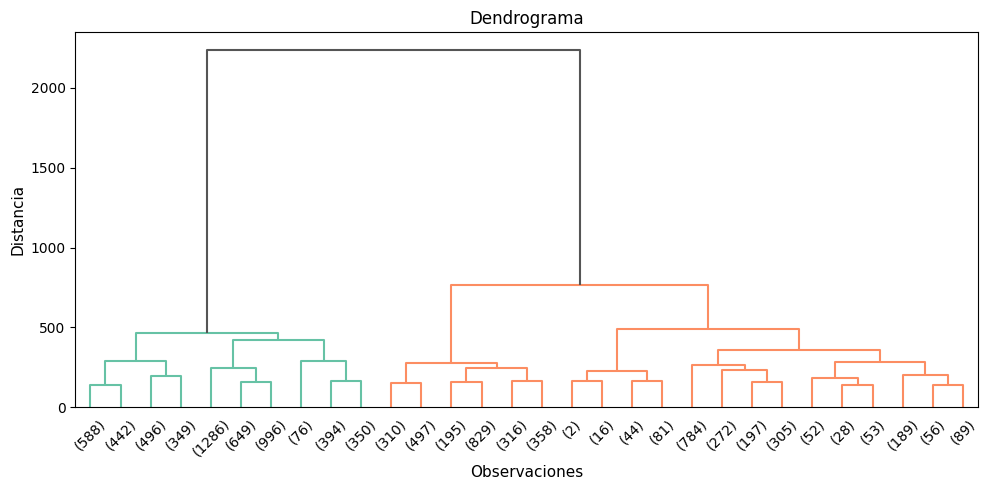

Distancia de las últimas fusiones: [2237.  765.  491.  462.  419.]


In [15]:
# Calculamos el linkage
Z = linkage(X_pca, method='ward')

# Dibujamos el dendrograma
colors = [to_hex(c) for c in plt.cm.Set2.colors]
set_link_color_palette(colors)

fig, ax = plt.subplots(figsize=(10, 5))
dendrogram(Z, ax=ax, truncate_mode="lastp", above_threshold_color="#555555")
set_link_color_palette(None)
ax.set_title("Dendrograma", fontsize=12)
ax.set_xlabel("Observaciones", fontsize=11)
ax.set_ylabel("Distancia", fontsize=11)
plt.tight_layout()
plt.show()

print("Distancia de las últimas fusiones:", Z[-5:, 2][::-1].round(0))

En el dendrograma se ve enseguida que la división en 2 grupos es, por lejos, la más fuerte. La última fusión (la que junta todo en un solo grupo) ocurre a una distancia de 2.237, mientras que todas las anteriores están por debajo de 800.

In [16]:
# Cortamos el dendrograma en distintos niveles para formar clusters
silhouette_jerarquico = {}
etiquetas_jerarquico = {}

for i in range(2, 9):
    etiquetas_jerarquico[i] = ordenar_por_tamanio(fcluster(Z, t=i, criterion='maxclust'))

    silhouette_jerarquico[i] = silhouette_score(X_pca, etiquetas_jerarquico[i])
    print(f"{i} clusters: silhouette = {silhouette_jerarquico[i]:.3f}")

2 clusters: silhouette = 0.460
3 clusters: silhouette = 0.340
4 clusters: silhouette = 0.337
5 clusters: silhouette = 0.160
6 clusters: silhouette = 0.158
7 clusters: silhouette = 0.152
8 clusters: silhouette = 0.147


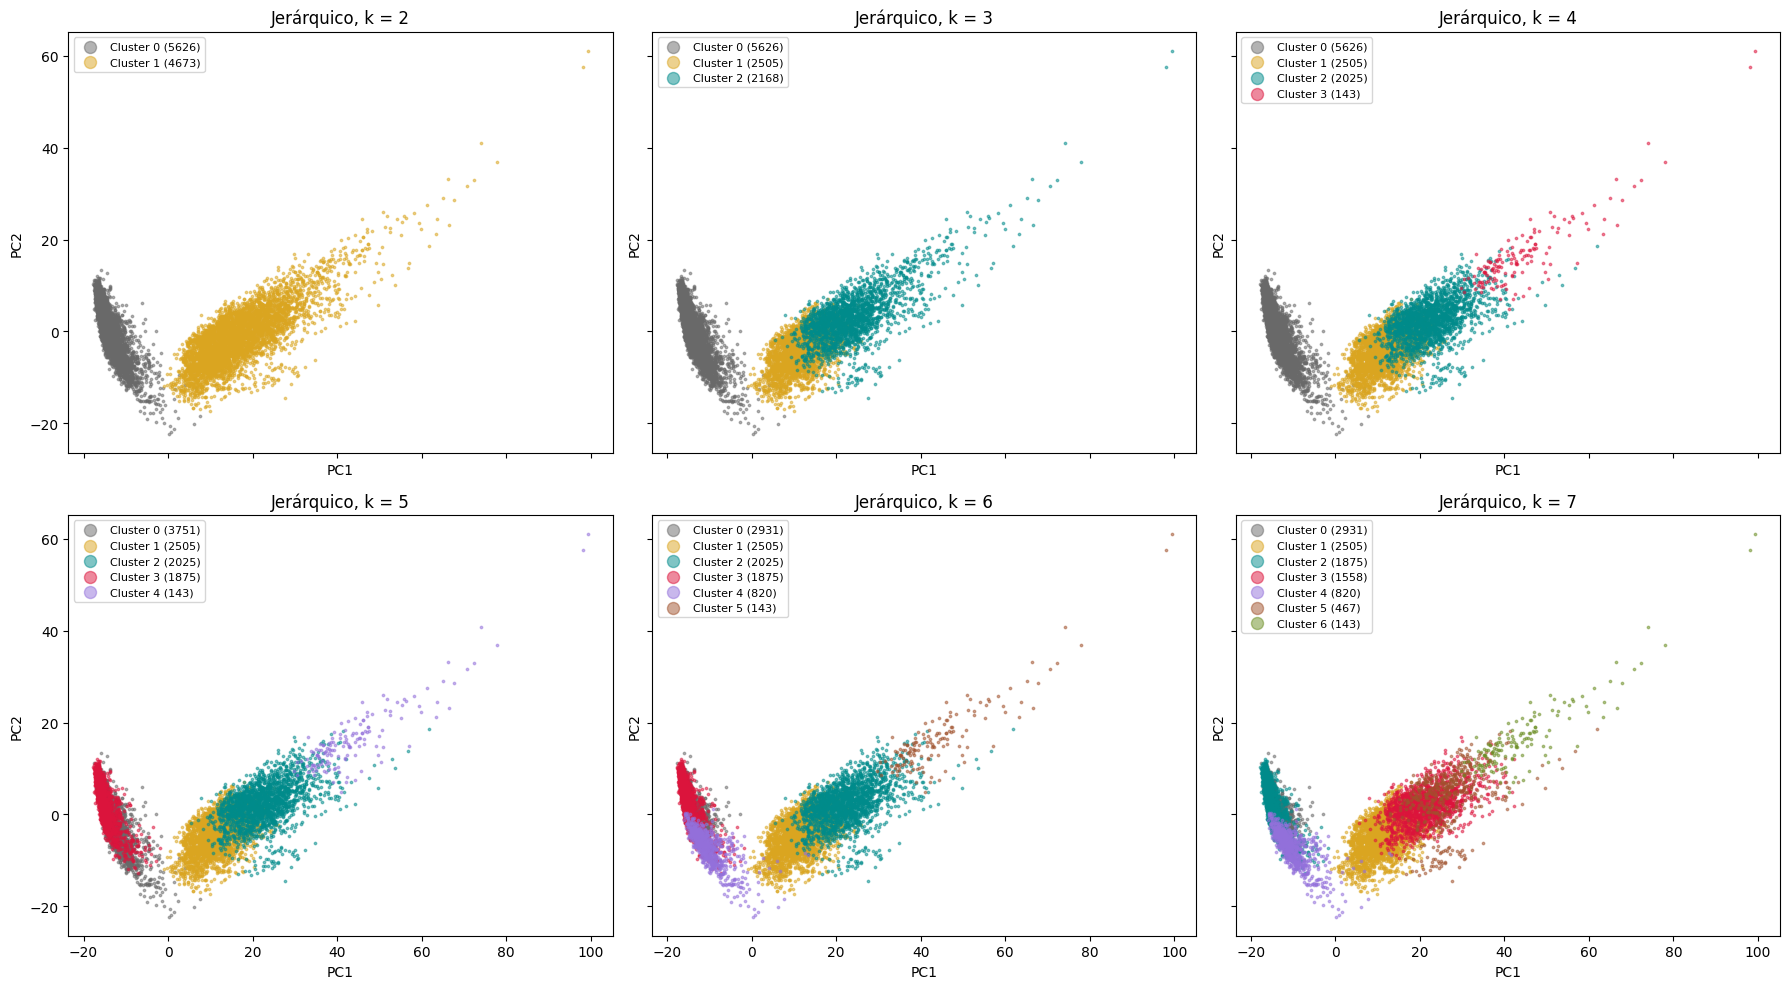

In [17]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharex=True, sharey=True)
for ax, k in zip(axes.flatten(), range(2, 8)):
    graficar_clusters(ax, etiquetas_jerarquico[k], f"Jerárquico, k = {k}")
plt.tight_layout()
plt.show()

**Cómo divide cada algoritmo.** Comparando los gráficos de K-Means y del jerárquico:
- Con k = 2, los dos separan las dos nubes de PCA.
- Con k = 3, los dos parten la nube de la derecha a lo largo de PC1.
- Con k = 4 empiezan a diferenciarse: K-Means corta en dos la nube compacta de la izquierda, mientras que el jerárquico la deja entera y separa un grupo chico en la punta de la nube de la derecha.

### HDBSCAN

Primero probamos DBSCAN, pero usa un único radio de vecindad (`eps`) para todo el espacio. Los grupos en este caso tienen densidades muy distintas: la nube de reposo es muy compacta y la de movimiento, mucho más dispersa. Por eso pasamos a HDBSCAN, que se adapta a zonas de distinta densidad.

Su parámetro principal es `min_cluster_size`, el tamaño mínimo que tiene que tener un grupo para considerarlo un cluster. Probamos varios valores y miramos cuántos clusters aparecen y cuántos puntos quedan como ruido.

In [18]:
resultados_hdbscan = {}
filas = []

for min_cluster_size in [10, 25, 50, 200, 500, 1000]:
    etiquetas = ordenar_por_tamanio(HDBSCAN(min_cluster_size=min_cluster_size).fit_predict(X_pca))
    resultados_hdbscan[min_cluster_size] = etiquetas

    filas.append({
        "min_cluster_size": min_cluster_size,
        "clusters": etiquetas.max() + 1,
        "% ruido": round((etiquetas == -1).mean() * 100, 1),
    })

pd.DataFrame(filas)

,min_cluster_size,clusters,% ruido
0,10,7,35.1
1,25,2,34.8
2,50,2,41.4
3,200,2,43.6
4,500,2,47.1
5,1000,0,100.0


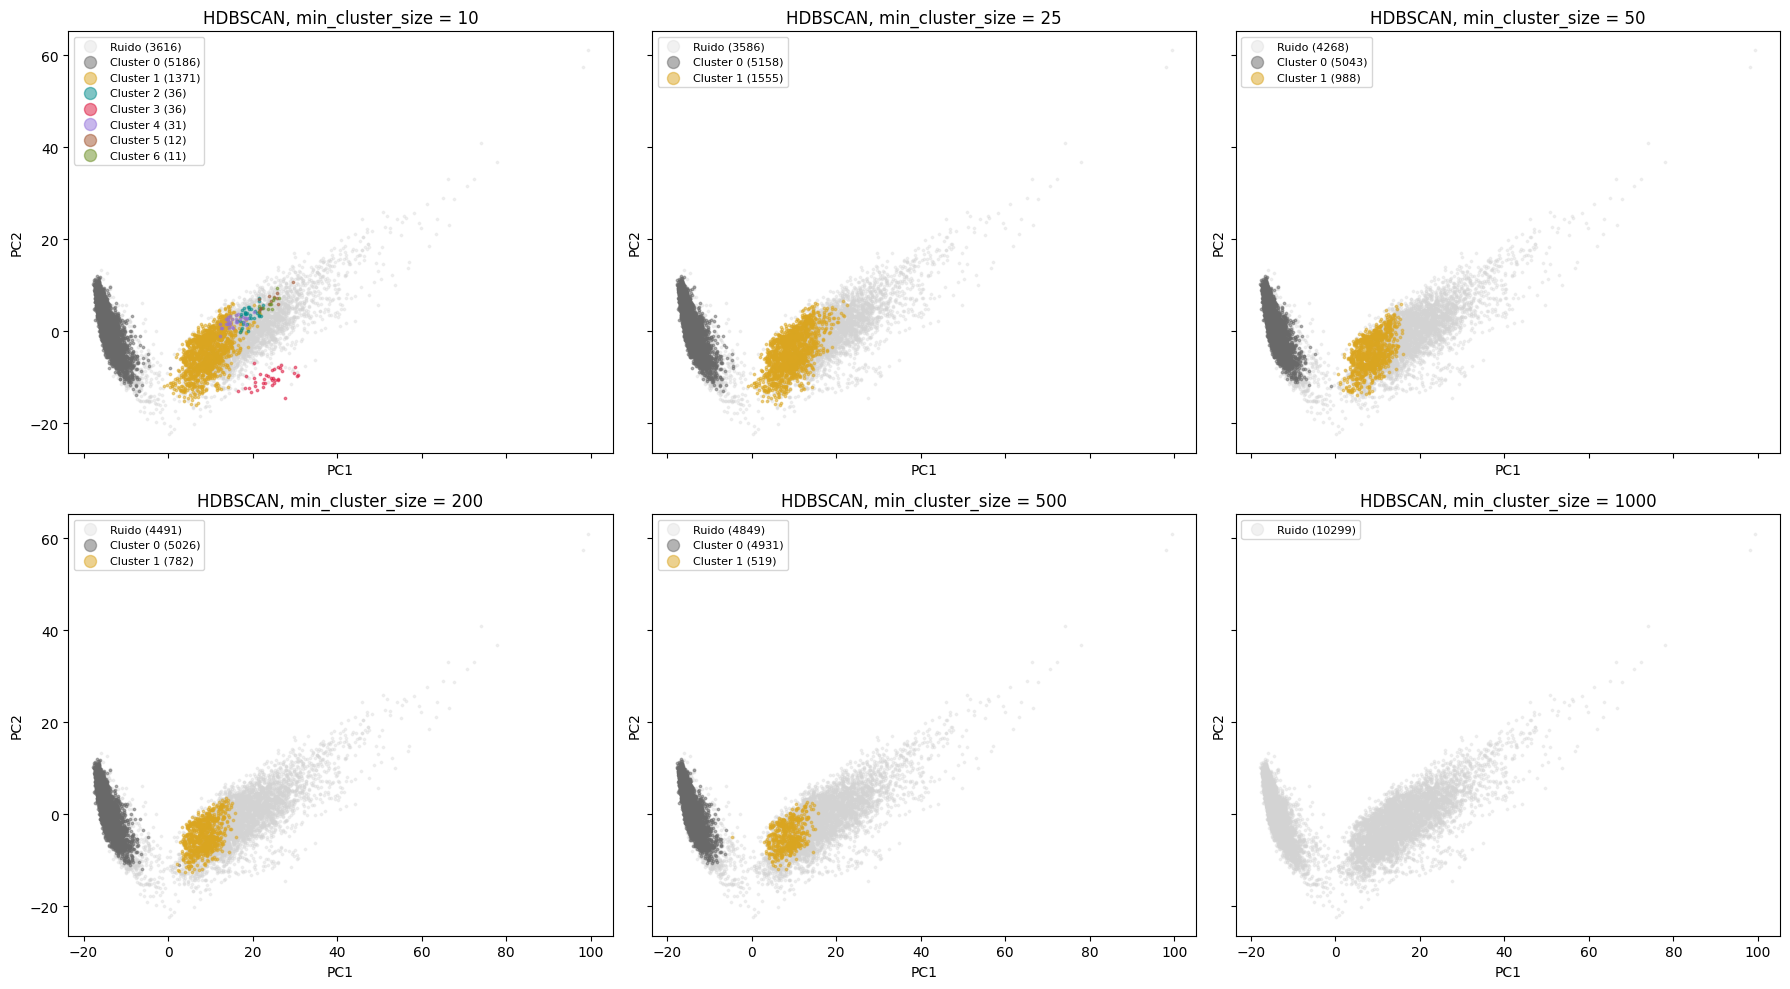

In [19]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharex=True, sharey=True)
for ax, min_cluster_size in zip(axes.flatten(), resultados_hdbscan):
    graficar_clusters(ax, resultados_hdbscan[min_cluster_size], f"HDBSCAN, min_cluster_size = {min_cluster_size}")
plt.tight_layout()
plt.show()

# Nos quedamos con min_cluster_size = 25: el que deja menos ruido
etiquetas_hdbscan = resultados_hdbscan[25]

Esto es lo que vemos al variar `min_cluster_size`:
- Con un valor chico (10), HDBSCAN acepta como clusters grupitos de unas pocas decenas de puntos dentro de la nube de la derecha, y termina con 7 clusters.
- Entre 25 y 500 encuentra siempre 2 clusters: la nube de la izquierda entera (cluster 0) y un núcleo de la nube de la derecha (cluster 1). A medida que subimos el valor, se vuelve más exigente con la densidad y el cluster 1 se achica (de 1.555 a 518 puntos) y el ruido crece (del 35% al 47%).
- Con 1.000 queda todo como ruido. Esto pasa porque, por defecto, HDBSCAN no puede devolver todo el dataset como un único cluster, y con ese mínimo el núcleo de la nube de la derecha ya no alcanza para formar un segundo cluster.

Nos quedamos con `min_cluster_size = 25`, que es el que deja menos ruido, para compararlo más adelante con los otros métodos. Aun así, incluso en ese caso un tercio de los datos queda sin asignar, casi todo en la nube de la derecha. Esa nube no está formada por grupos densos separados, sino por un continuo de puntos cada vez más dispersos, y un método de densidad no tiene cómo agruparla.

A HDBSCAN no lo evaluamos con la silueta. La silueta supone que todos los puntos están asignados a algún cluster. Si la calculamos sin el ruido, mide solo los puntos de las zonas densas y da un valor inflado. Si tratamos al ruido como un grupo más, lo castiga por no ser compacto. Por eso lo evaluamos por la cantidad de ruido y por los gráficos. Más adelante lo comparamos con los otros métodos con ARI y AMI.

## 3c. Evaluación y comparación

Como HDBSCAN no fija la cantidad de clusters y además deja una parte de los datos como ruido, la elección de k la hacemos entre K-Means y el jerárquico.

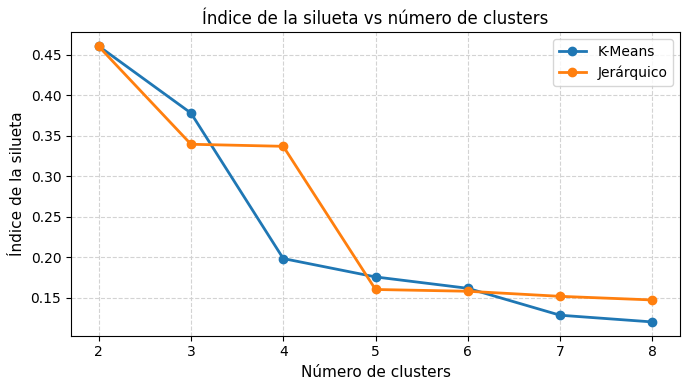

In [20]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(list(silhouette_kmeans), list(silhouette_kmeans.values()), "o-", lw=2, label="K-Means")
ax.plot(list(silhouette_jerarquico), list(silhouette_jerarquico.values()), "o-", lw=2, label="Jerárquico")
ax.set_xlabel("Número de clusters", fontsize=11)
ax.set_ylabel("Índice de la silueta", fontsize=11)
ax.set_title("Índice de la silueta vs número de clusters", fontsize=12)
ax.legend(fontsize=10)
plt.grid(True, ls='--', color='lightgray')
plt.tight_layout()
plt.show()

De la silueta sacamos lo siguiente:
- Con k = 2, los dos algoritmos tienen su mejor valor (0.46), que corresponde a la separación entre las dos nubes.
- Con k = 3, K-Means queda mejor que el jerárquico (0.378 contra 0.340).
- Con k = 4, K-Means cae a 0.199, mientras que el jerárquico se mantiene (0.337).
- De k = 5 en adelante, los dos quedan por debajo de 0.18.

Tomamos k = 2, 3 y 4 como candidatos y los comparamos también por su estabilidad.

### Estabilidad por bootstrapping

Usamos la función de estabilidad de la notebook de clase (`clase_06_c_estabilidad`) con dos cambios. Le pasamos como parámetro el algoritmo a reentrenar (en la original estaba fijo en GMM), y en cada submuestra evalúa los tres valores de k juntos. En el caso del jerárquico, eso permite calcular la jerarquía una sola vez por submuestra y cortarla en k = 2, 3 y 4.

El resto es igual: en cada iteración toma el 80% de los datos, reentrena, alinea las etiquetas nuevas con las originales y calcula el índice de Jaccard de cada cluster, es decir, qué proporción de sus puntos sigue junta. Usamos 30 submuestras en lugar de 50 porque cada reentrenamiento del jerárquico recalcula toda la jerarquía y tarda bastante. Como en clase, tomamos 0.75 como umbral de alta estabilidad.

In [21]:
def jaccard_por_cluster(etiquetas_base, etiquetas_nuevas):
    """Alinea las etiquetas nuevas con las originales y calcula el índice de Jaccard de cada cluster."""
    k = len(np.unique(etiquetas_base))
    k_nuevo = max(k, len(np.unique(etiquetas_nuevas)))

    # Matriz de contingencia para emparejar los clusters originales con los nuevos
    contingency = np.zeros((k, k_nuevo))
    for i in range(k):
        for j in range(k_nuevo):
            contingency[i, j] = np.sum((etiquetas_base == i) & (etiquetas_nuevas == j))

    # Mejor correspondencia de etiquetas
    row_ind, col_ind = linear_sum_assignment(-contingency)
    mapping = {col: row for row, col in zip(row_ind, col_ind)}
    alineadas = np.array([mapping.get(e, -1) for e in etiquetas_nuevas])

    jaccard = {}
    for i in range(k):
        interseccion = np.sum((etiquetas_base == i) & (alineadas == i))
        union = np.sum((etiquetas_base == i) | (alineadas == i))
        if union > 0:
            jaccard[i] = interseccion / union
    return jaccard


def compute_jaccard_stability(X, etiquetas_base, ajustar, n_bootstraps=30, sample_ratio=0.8, random_state=RANDOM_STATE):
    """
    etiquetas_base: {k: etiquetas del modelo entrenado con todos los datos}
    ajustar: función que recibe una submuestra y devuelve {k: etiquetas} reentrenando el algoritmo
    """
    rng = np.random.default_rng(random_state)
    resultados = {k: {i: [] for i in range(k)} for k in etiquetas_base}

    for _ in range(n_bootstraps):
        indices = rng.choice(len(X), int(len(X) * sample_ratio), replace=False)
        etiquetas_sub = ajustar(X[indices])
        for k in etiquetas_base:
            for i, valor in jaccard_por_cluster(etiquetas_base[k][indices], etiquetas_sub[k]).items():
                resultados[k][i].append(valor)
    return resultados

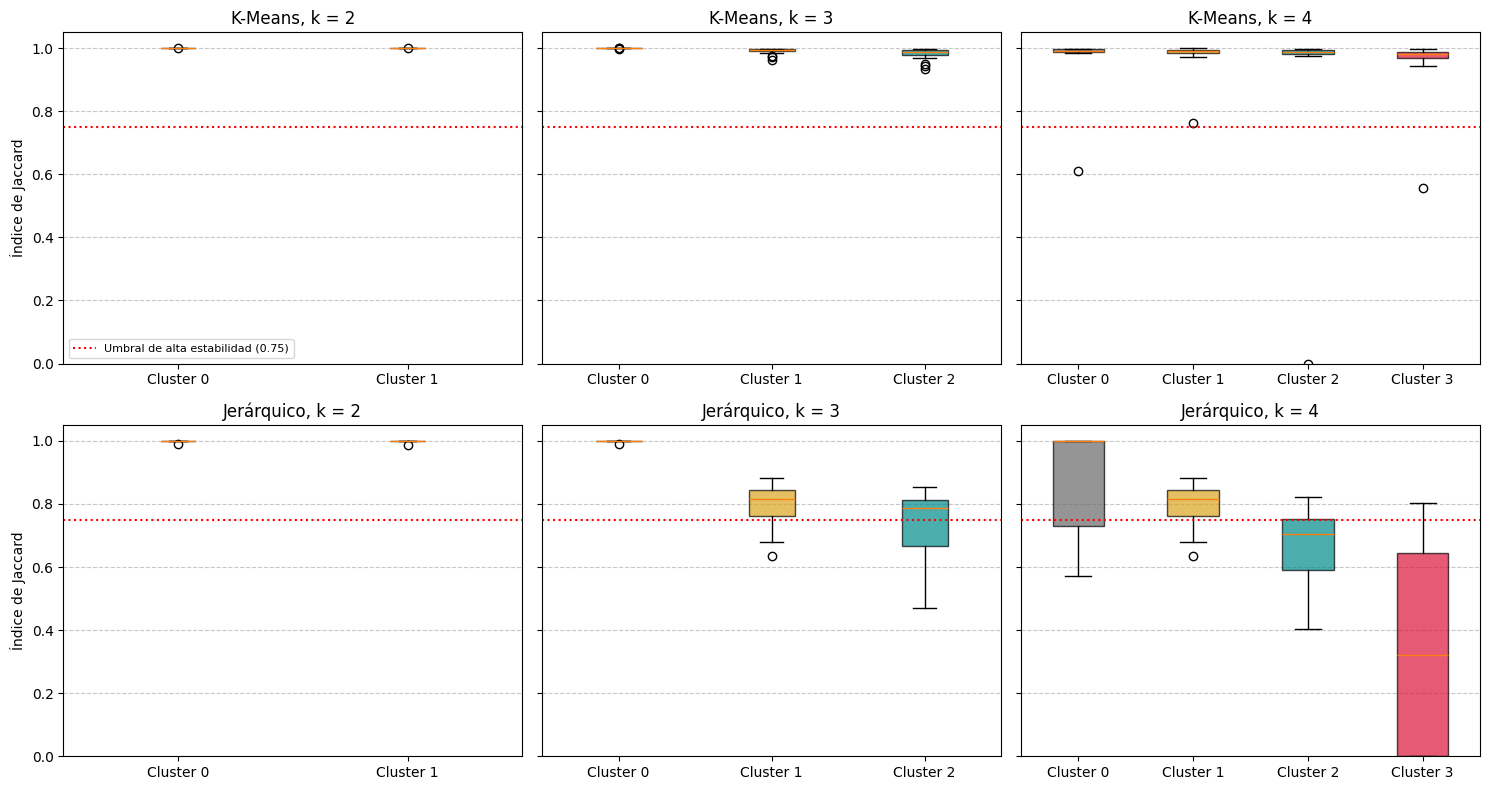

Mediana del índice de Jaccard por cluster:


K-Means               Jerárquico              
                2      3      4          2      3      4
Cluster 0     1.0  1.000  0.992        1.0  1.000  1.000
Cluster 1     1.0  0.993  0.991        1.0  0.815  0.815
Cluster 2     NaN  0.986  0.988        NaN  0.787  0.705
Cluster 3     NaN    NaN  0.983        NaN    NaN  0.322

In [22]:
K_CANDIDATOS = [2, 3, 4]

def ajustar_kmeans(X_sub):
    return {k: KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=RANDOM_STATE).fit_predict(X_sub)
            for k in K_CANDIDATOS}

def ajustar_jerarquico(X_sub):
    Z_sub = linkage(X_sub, method="ward")
    return {k: fcluster(Z_sub, t=k, criterion="maxclust") - 1 for k in K_CANDIDATOS}

estabilidad = {
    "K-Means": compute_jaccard_stability(X_pca, {k: etiquetas_kmeans[k] for k in K_CANDIDATOS}, ajustar_kmeans),
    "Jerárquico": compute_jaccard_stability(X_pca, {k: etiquetas_jerarquico[k] for k in K_CANDIDATOS}, ajustar_jerarquico),
}

fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharey=True)
for fila, (algoritmo, resultados) in enumerate(estabilidad.items()):
    for col, k in enumerate(K_CANDIDATOS):
        ax = axes[fila, col]
        bp = ax.boxplot([resultados[k][i] for i in range(k)], tick_labels=[f"Cluster {i}" for i in range(k)], patch_artist=True)
        for patch, color in zip(bp["boxes"], COLORES_CLUSTERS):
            patch.set_facecolor(color)
            patch.set_alpha(0.7)
        ax.axhline(y=0.75, color="r", linestyle=":", label="Umbral de alta estabilidad (0.75)")
        ax.set_title(f"{algoritmo}, k = {k}")
        ax.set_ylim(0, 1.05)
        ax.grid(axis="y", linestyle="--", alpha=0.7)
    axes[fila, 0].set_ylabel("Índice de Jaccard")
axes[0, 0].legend(loc="lower left", fontsize=8)
plt.tight_layout()
plt.show()

medianas = pd.DataFrame({
    (algoritmo, k): {f"Cluster {i}": np.median(resultados[k][i]) for i in range(k)}
    for algoritmo, resultados in estabilidad.items() for k in K_CANDIDATOS
}).round(3)
print("Mediana del índice de Jaccard por cluster:")
medianas

K-Means es muy estable en los tres casos, con todas las medianas cerca de 1. El jerárquico es perfectamente estable con k = 2, pasa el umbral con k = 3 (aunque con menos margen que K-Means) y deja de ser estable con k = 4. Uno de sus clusters baja a 0.705 y el cluster más chico, a 0.32. Ese grupo chico aparece o desaparece según la submuestra, así que no lo podemos tomar como un grupo real.

Algo a tener en cuenta es que estabilidad no es lo mismo que separación. Un algoritmo puede cortar los datos siempre igual aunque ese corte no siga una frontera natural, que es lo que le pasa a K-Means con k = 4. Es estable, pero su silueta es muy baja. Por eso miramos las dos cosas juntas. Con eso descartamos k = 4 en los dos algoritmos (por silueta en K-Means y por estabilidad en el jerárquico).

### Silueta por cluster

El promedio de la silueta puede esconder clusters con muchos puntos mal ubicados, así que miramos también el gráfico de silueta por cluster. Lo hacemos para k = 2, que es la división más obvia, y para k = 3, que agrega una división más.

K-Means, K=2 - cluster 0: 0% de puntos con silueta negativa
K-Means, K=2 - cluster 1: 1% de puntos con silueta negativa
Jerárquico, K=2 - cluster 0: 0% de puntos con silueta negativa
Jerárquico, K=2 - cluster 1: 1% de puntos con silueta negativa
K-Means, K=3 - cluster 0: 0% de puntos con silueta negativa
K-Means, K=3 - cluster 1: 0% de puntos con silueta negativa
K-Means, K=3 - cluster 2: 46% de puntos con silueta negativa
Jerárquico, K=3 - cluster 0: 0% de puntos con silueta negativa
Jerárquico, K=3 - cluster 1: 0% de puntos con silueta negativa
Jerárquico, K=3 - cluster 2: 51% de puntos con silueta negativa


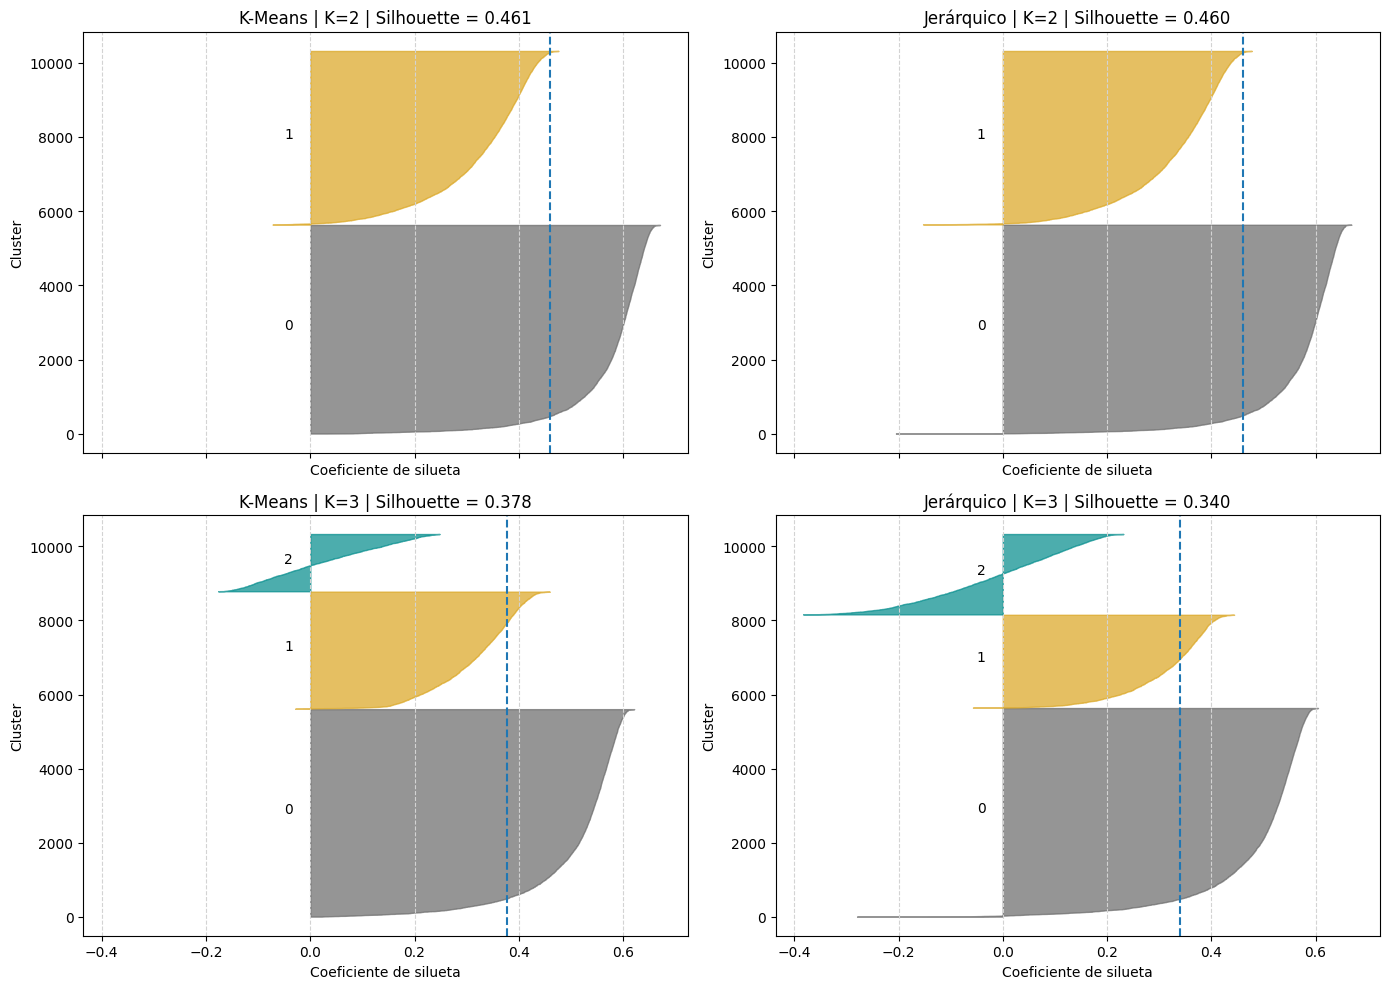

In [23]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True)

for fila, k_eval in enumerate([2, 3]):
    for ax, (nombre, etiquetas) in zip(axes[fila], [("K-Means", etiquetas_kmeans), ("Jerárquico", etiquetas_jerarquico)]):
        clusters = etiquetas[k_eval]
        silhouette_vals = silhouette_samples(X_pca, clusters)
        silhouette_avg = silhouette_score(X_pca, clusters)

        y_lower = 10
        for c in np.unique(clusters):
            vals = silhouette_vals[clusters == c]
            vals.sort()
            y_upper = y_lower + len(vals)
            ax.fill_betweenx(np.arange(y_lower, y_upper), 0, vals, alpha=0.7, color=COLORES_CLUSTERS[c])
            ax.text(-0.05, (y_lower + y_upper) / 2, str(c))
            y_lower = y_upper + 10
            print(f"{nombre}, K={k_eval} - cluster {c}: {(vals < 0).mean():.0%} de puntos con silueta negativa")

        ax.axvline(silhouette_avg, linestyle="--")
        ax.grid(axis='x', ls='--', color='lightgray')
        ax.set_xlabel("Coeficiente de silueta")
        ax.set_ylabel("Cluster")
        ax.set_title(f"{nombre} | K={k_eval} | Silhouette = {silhouette_avg:.3f}")

plt.tight_layout()
plt.show()

Con k = 2, los dos algoritmos dan clusters bien definidos. Prácticamente ningún punto tiene silueta negativa (como mucho el 1%). El cluster 0, el de reposo, es el más compacto, y el de movimiento tiene una silueta más baja porque es una nube más dispersa.

Con k = 3, los clusters 0 y 1 siguen bien definidos, pero en los dos algoritmos el nuevo cluster 2 tiene casi la mitad de sus puntos con silueta negativa (46% en K-Means y 51% en el jerárquico). Es decir, puntos que están más cerca del cluster 1 que del propio. Coincide con lo que vimos con HDBSCAN: la nube de movimiento es un continuo, y partirla en dos es cortar a lo largo de un gradiente más que separar grupos naturales.

**Consenso entre algoritmos.** Como en la notebook de clase, comparamos los tres algoritmos entre sí con ARI y AMI (1 es coincidencia perfecta y 0, lo que se esperaría por azar). Para K-Means y el jerárquico usamos las soluciones con k = 3, y para HDBSCAN, la de `min_cluster_size = 25`. En HDBSCAN, el ruido (etiqueta -1) cuenta como un grupo más, igual que en la notebook de clase. Como el ruido no es un grupo real sino puntos sin asignar, esto baja su coincidencia con los otros métodos.

In [24]:
# De acá en adelante trabajamos con k = 3
K = 3

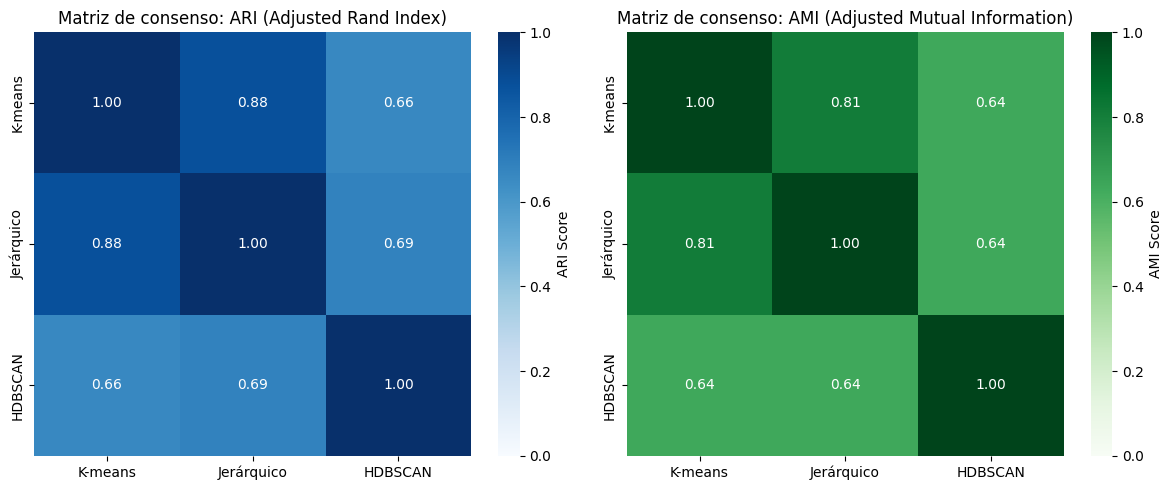

In [25]:
labels_dict = {
    "K-means": etiquetas_kmeans[K],
    "Jerárquico": etiquetas_jerarquico[K],
    "HDBSCAN": etiquetas_hdbscan,
}

metodos = list(labels_dict.keys())
n = len(metodos)

matriz_ari = np.eye(n)
matriz_ami = np.eye(n)

# Calcula las métricas para cada par de métodos
for i in range(n):
    for j in range(n):
        if i != j:
            m1, m2 = metodos[i], metodos[j]
            matriz_ari[i, j] = adjusted_rand_score(labels_dict[m1], labels_dict[m2])
            matriz_ami[i, j] = adjusted_mutual_info_score(labels_dict[m1], labels_dict[m2])

df_ari = pd.DataFrame(matriz_ari, index=metodos, columns=metodos)
df_ami = pd.DataFrame(matriz_ami, index=metodos, columns=metodos)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(df_ari, annot=True, fmt='.2f', cmap='Blues', vmin=0, vmax=1, ax=axes[0], cbar_kws={'label': 'ARI Score'})
axes[0].set_title('Matriz de consenso: ARI (Adjusted Rand Index)', fontsize=12)
sns.heatmap(df_ami, annot=True, fmt='.2f', cmap='Greens', vmin=0, vmax=1, ax=axes[1], cbar_kws={'label': 'AMI Score'})
axes[1].set_title('Matriz de consenso: AMI (Adjusted Mutual Information)', fontsize=12)
plt.tight_layout()
plt.show()

K-Means y el jerárquico coinciden bastante (ARI 0.88): con k = 3 encuentran prácticamente la misma estructura. HDBSCAN coincide menos con los dos, principalmente porque deja un tercio de los datos como ruido.

**Selección: K-Means con k = 3.**

Con k = 3, K-Means es mejor que el jerárquico en todas las métricas. Tiene una silueta promedio más alta (0.378 contra 0.340), un poco menos de puntos mal ubicados en el cluster 2 (46% con silueta negativa, contra 51%) y es bastante más estable: las medianas de Jaccard de sus tres clusters son 1.0, 0.99 y 0.99, mientras que las del jerárquico son 1.0, 0.82 y 0.79. Además, es más simple y rápido. Su única desventaja frente al jerárquico es que no da una jerarquía. Para ver otros niveles hay que volver a entrenarlo con otro k. El jerárquico tiene justamente esa ventaja, porque su dendrograma muestra la estructura por niveles y la fuerza de cada división, pero al pedirle más detalle (k = 4) deja de ser estable.

Por eso elegimos K-Means, que encuentra prácticamente la misma estructura que el jerárquico con mejores métricas. El jerárquico igual nos sirvió, porque su dendrograma muestra que la división en 2 grupos es mucho más fuerte que las demás.

La elección de k = 3 es más discutible. Según la silueta, k = 2 es la mejor partición y la única división claramente natural (movimiento vs. reposo). Aun así nos quedamos con k = 3, sabiendo que es un compromiso. Agrega una división del movimiento según su intensidad que se puede interpretar desde el dominio y que es muy estable (Jaccard de 0.99 o más). Lo que no hace es separar grupos naturales: corta un continuo, y por eso casi la mitad de los puntos del cluster 2 tienen silueta negativa. k = 4 ya no se justifica, porque la silueta de K-Means cae a 0.199.

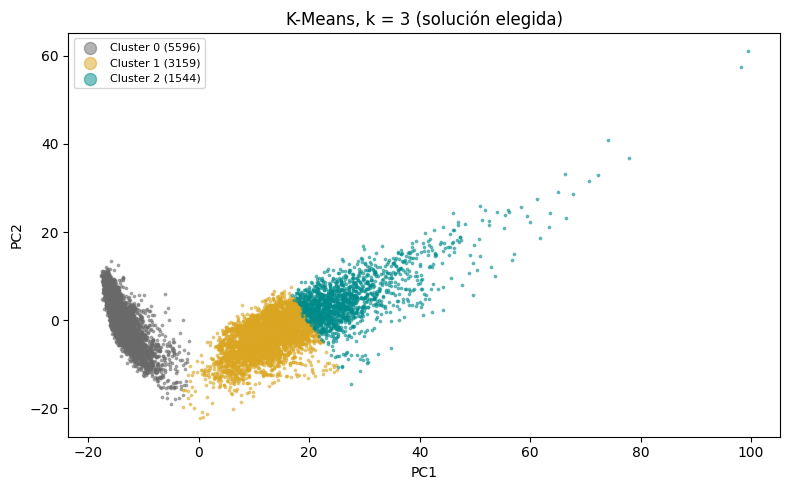

In [26]:
clusters = etiquetas_kmeans[K]
df["cluster"] = clusters

fig, ax = plt.subplots(figsize=(8, 5))
graficar_clusters(ax, clusters, f"K-Means, k = {K} (solución elegida)")
plt.tight_layout()
plt.show()

En la proyección sobre las dos primeras componentes, el cluster 0 es la nube compacta de la izquierda y la nube de la derecha queda partida en dos a lo largo de PC1, es decir, según la intensidad del movimiento.

**Validación externa.** Con la solución ya elegida, recién ahora comparamos los clusters con la actividad real usando ARI y AMI. No los usamos para elegir, pero sirven como control.

Como tenemos 3 clusters y 6 actividades, la comparación directa nunca podría dar una coincidencia perfecta. Por eso también comparamos contra una agrupación de las actividades en 3 grupos, definida desde el dominio y no a partir de los clusters: reposo (sentado, parado y acostado), caminar y escaleras (subir y bajar).

In [27]:
grupos_actividad = actividad.map({
    "SITTING": "Reposo", "STANDING": "Reposo", "LAYING": "Reposo",
    "WALKING": "Caminar",
    "WALKING_UPSTAIRS": "Escaleras", "WALKING_DOWNSTAIRS": "Escaleras",
})

externa = pd.DataFrame({
    nombre: {
        "ARI vs 6 actividades": adjusted_rand_score(actividad, etiquetas[K]),
        "AMI vs 6 actividades": adjusted_mutual_info_score(actividad, etiquetas[K]),
        "ARI vs 3 grupos": adjusted_rand_score(grupos_actividad, etiquetas[K]),
        "AMI vs 3 grupos": adjusted_mutual_info_score(grupos_actividad, etiquetas[K]),
    }
    for nombre, etiquetas in [("K-Means", etiquetas_kmeans), ("Jerárquico", etiquetas_jerarquico)]
}).round(3)
externa

,K-Means,Jerárquico
ARI vs 6 actividades,0.332,0.360
AMI vs 6 actividades,0.519,0.560
ARI vs 3 grupos,0.777,0.786
AMI vs 3 grupos,0.684,0.692


Contra las 6 actividades, la coincidencia es baja (ARI de 0.33 para K-Means y 0.36 para el jerárquico), pero contra los 3 grupos sube mucho (0.78 y 0.79). O sea, la mayor parte de la diferencia con las 6 actividades viene de que los clusters no separan entre sí las actividades en reposo. Para sentado y parado era lo esperado (hipótesis 3). Para acostado, en cambio, va en contra de lo que planteaba la hipótesis 2, y lo analizamos más adelante.

La coincidencia con los 3 grupos tampoco es perfecta, porque los clusters no dividen el movimiento en "caminar" y "escaleras", sino según su intensidad: subir escaleras queda junto con la mayor parte de caminar, y bajar escaleras se reparte. Lo vamos a ver en detalle en la interpretación.

En las dos comparaciones el jerárquico queda apenas por encima de K-Means, al revés de lo que mostraban las métricas internas. La diferencia es chica y no cambia la elección, que hicimos solo con métricas que no usan la actividad.

## 3d. Interpretación de los clusters

### Composición según la actividad

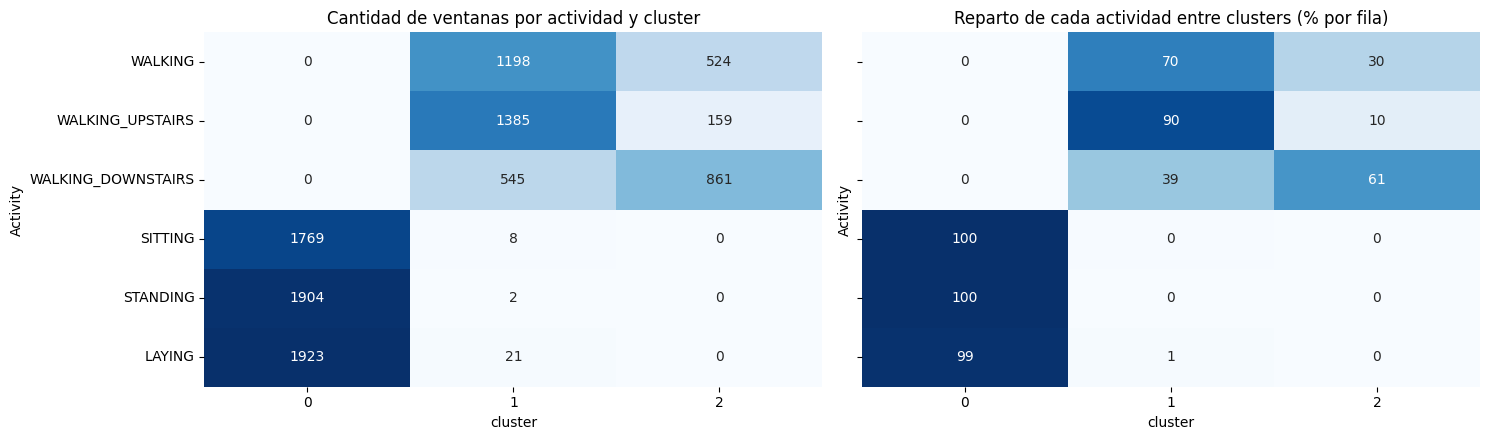

In [28]:
composicion = pd.crosstab(actividad, df["cluster"]).reindex(ORDEN_ACTIVIDADES)
reparto_pct = pd.crosstab(actividad, df["cluster"], normalize="index").reindex(ORDEN_ACTIVIDADES) * 100

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5), sharey=True)
sns.heatmap(composicion, annot=True, fmt="d", cmap="Blues", ax=axes[0], cbar=False)
axes[0].set_title("Cantidad de ventanas por actividad y cluster")
sns.heatmap(reparto_pct, annot=True, fmt=".0f", cmap="Blues", ax=axes[1], cbar=False)
axes[1].set_title("Reparto de cada actividad entre clusters (% por fila)")
plt.tight_layout()
plt.show()

- **Cluster 0 (5.596 ventanas): reposo.** Tiene el 99% o más de las ventanas de sentado, parado y acostado, y ninguna de movimiento. Solo 31 ventanas de reposo quedaron del otro lado, así que la división entre movimiento y reposo es casi perfecta, como esperábamos en la hipótesis 1.
- **Cluster 1 (3.159 ventanas): movimiento de intensidad moderada.** Se queda con el 90% de las ventanas de subir escaleras, el 70% de las de caminar y el 39% de las de bajar escaleras.
- **Cluster 2 (1.544 ventanas): movimiento de intensidad alta.** Tiene el 61% de las ventanas de bajar escaleras, el 30% de las de caminar y el 10% de las de subir escaleras.

Los clusters no reproducen las 6 actividades. Las tres actividades en reposo caen todas juntas en el cluster 0, sin distinguirse (hipótesis 3: sentado y parado no se separan, y en este caso acostado tampoco). Entre las de movimiento hay bastante mezcla (hipótesis 4): subir escaleras queda casi entera en el cluster 1, pero bajar escaleras y caminar se reparten entre los dos.

### ¿Qué variables distinguen a cada cluster?

Elegimos algunas variables fáciles de interpretar y comparamos su valor medio en cada cluster. Están estandarizadas, así que 0 es el promedio del dataset y cada unidad es un desvío.

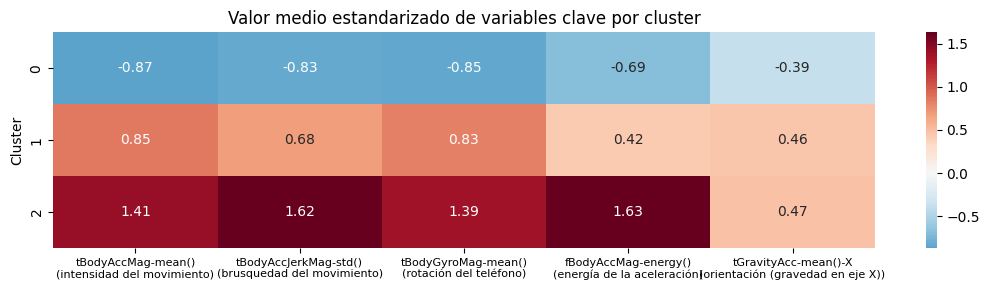

In [29]:
variables_clave = {
    "tBodyAccMag-mean()": "intensidad del movimiento",
    "tBodyAccJerkMag-std()": "brusquedad del movimiento",
    "tBodyGyroMag-mean()": "rotación del teléfono",
    "fBodyAccMag-energy()": "energía de la aceleración",
    "tGravityAcc-mean()-X": "orientación (gravedad en eje X)",
}

perfil = pd.DataFrame(X_std, columns=X.columns)[list(variables_clave)].groupby(clusters).mean()
perfil.columns = [f"{v}\n({d})" for v, d in variables_clave.items()]

plt.figure(figsize=(11, 3))
sns.heatmap(perfil, annot=True, fmt=".2f", cmap="RdBu_r", center=0)
plt.title("Valor medio estandarizado de variables clave por cluster")
plt.ylabel("Cluster")
plt.xticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.show()

El mapa de calor muestra que los clusters quedan ordenados según la intensidad del movimiento. El cluster 0 está por debajo del promedio en las cuatro medidas de movimiento (intensidad, brusquedad, rotación y energía), como corresponde a un cuerpo quieto. Los clusters 1 y 2 están por encima, y el 2 supera al 1 en todas. Por ejemplo, la brusquedad pasa de 0.68 a 1.62 desvíos sobre el promedio, y la energía, de 0.42 a 1.63. En cambio, la orientación del teléfono es prácticamente igual en los dos clusters de movimiento. Es decir, lo que los separa no es cómo está el teléfono, sino cuánto y qué tan bruscamente se mueve la persona.

Esto tiene sentido desde el dominio. Subir escaleras es un movimiento más lento y controlado, y por eso cae casi entero en el cluster 1. Bajar escaleras, en cambio, implica un impacto en cada escalón, y se inclina hacia el cluster 2. Caminar en llano queda a mitad de camino: la mayor parte cae en el cluster 1, pero casi un tercio va al 2.

### ¿Los clusters en movimiento dependen de la persona?

En la hipótesis 4 planteamos que la forma de moverse de cada persona podía influir. Para verlo, miramos cómo se reparten las ventanas en movimiento de cada persona entre los clusters 1 y 2.

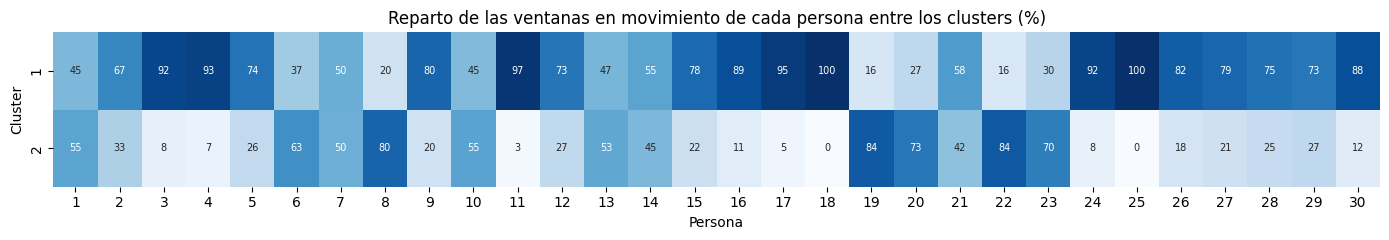

Personas con más del 90% de sus ventanas en movimiento en un solo cluster: 7 de 30
{3: 'cluster 1 (92%)', 4: 'cluster 1 (93%)', 11: 'cluster 1 (97%)', 17: 'cluster 1 (95%)', 18: 'cluster 1 (100%)', 24: 'cluster 1 (92%)', 25: 'cluster 1 (100%)'}


In [30]:
en_movimiento = df["cluster"] != 0
reparto_sujetos = pd.crosstab(df.loc[en_movimiento, "subject"], df.loc[en_movimiento, "cluster"], normalize="index") * 100

plt.figure(figsize=(14, 2.5))
sns.heatmap(reparto_sujetos.T, annot=True, fmt=".0f", cmap="Blues", cbar=False, annot_kws={"size": 7})
plt.title("Reparto de las ventanas en movimiento de cada persona entre los clusters (%)")
plt.xlabel("Persona")
plt.ylabel("Cluster")
plt.tight_layout()
plt.show()

concentradas = reparto_sujetos[reparto_sujetos.max(axis=1) > 90]
print(f"Personas con más del 90% de sus ventanas en movimiento en un solo cluster: {len(concentradas)} de {len(reparto_sujetos)}")
print({persona: f"cluster {fila.idxmax()} ({fila.max():.0f}%)" for persona, fila in concentradas.iterrows()})

Acá aparece algo interesante. Si los clusters dependieran solo de la actividad, cada persona debería repartirse más o menos igual, porque todas hicieron las mismas actividades. Pero 7 de las 30 personas tienen más del 90% de sus ventanas en movimiento en un mismo cluster, siempre el 1 (el de intensidad moderada), y para las personas 18 y 25 es el 100%. En el otro extremo, las personas 19 y 22 tienen el 84% en el cluster 2, y la persona 8, cerca del 80%.

Para estas personas, el clustering no distingue tanto qué actividad hacen sino cómo se mueven. Hay gente que se mueve con más energía que otra en todas las actividades. Esto confirma la segunda parte de la hipótesis 4.

### Observaciones representativas

Para cada cluster buscamos la ventana real más cercana al centroide, que sería el ejemplo más típico del grupo.

In [31]:
representativas = []
for k in range(K):
    indices = np.where(clusters == k)[0]
    centro = X_pca[indices].mean(axis=0)
    representativas.append(indices[np.argmin(np.linalg.norm(X_pca[indices] - centro, axis=1))])

df.loc[representativas, ["cluster", "Activity", "subject"] + list(variables_clave)].set_index("cluster").round(3)

,Activity,subject,tBodyAccMag-mean(),tBodyAccJerkMag-std(),tBodyGyroMag-mean(),fBodyAccMag-energy(),tGravityAcc-mean()-X
cluster,,,,,,,
0,SITTING,28,-0.978,-0.988,-0.982,-1.000,0.907
1,WALKING_UPSTAIRS,28,-0.209,-0.316,-0.328,-0.709,0.850
2,WALKING_UPSTAIRS,19,0.039,-0.072,0.076,-0.644,0.847


Los ejemplos típicos van en la misma línea (los valores de esta tabla están en la escala original, entre -1 y 1):
- En el cluster 0 aparece una ventana de sentado con los valores de movimiento en el piso de la escala (intensidad -0.98): el cuerpo está prácticamente quieto.
- En el cluster 1, una ventana de subir escaleras con intensidad intermedia (-0.21).
- En el cluster 2 aparece otra ventana de subir escaleras, pero de la persona 19 y con más intensidad (0.04).

Nos llamó la atención que el ejemplo típico del cluster más intenso sea una actividad que en general cae en el cluster 1. Encaja con el efecto de la persona: la persona 19 es una de las que tienen la mayoría de sus ventanas en el cluster 2, y sube escaleras con tanta intensidad que su ventana más típica termina ahí.

### ¿Por qué no se separa acostado?

La hipótesis 2 decía que acostado debería distinguirse por la orientación del teléfono, pero el clustering no lo separó. Para entender por qué, miramos la componente de la gravedad en el eje X del teléfono en cada actividad.

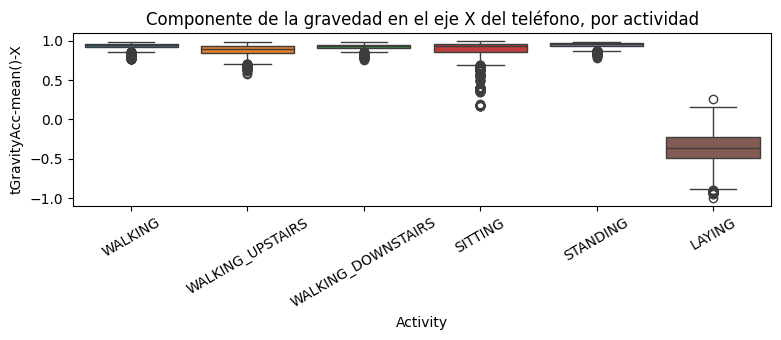

In [32]:
fig, ax = plt.subplots(figsize=(8, 3.5))
sns.boxplot(x=actividad, y=X["tGravityAcc-mean()-X"], order=ORDEN_ACTIVIDADES, palette=COLORES_ACTIVIDADES, ax=ax)
ax.set_title("Componente de la gravedad en el eje X del teléfono, por actividad")
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

La diferencia está y es muy clara: cuando la persona está acostada, la gravedad deja de actuar sobre el eje X del teléfono. Sin embargo, el clustering no la captura, por dos motivos.

Primero, la estandarización iguala la varianza de cada variable, pero no la de cada familia de variables. Como vimos al principio, las variables de gravedad y orientación son solo 60 de 561, mientras que las de movimiento son la gran mayoría y están muy correlacionadas entre sí. PCA las combina en las direcciones de mayor varianza (PC1 sola explica la mitad), así que en la representación reducida el movimiento pesa mucho más que la orientación.

Segundo, K-Means busca grupos con la menor dispersión interna posible. La nube de movimiento es mucho más dispersa que la diferencia entre acostado y el resto de las actividades en reposo, así que al pasar de 2 a 3 clusters le conviene más partir esa nube que separar acostado.

Por eso la hipótesis 2 se cumple solo en parte: acostado se distingue en las variables de orientación, pero no en los clusters. Más adelante vamos a ver que UMAP sí lo separa.

### Síntesis

El clustering captura dos niveles de estructura:
1. **Movimiento vs. reposo.** Es la señal dominante y la única división claramente natural. La encuentran los tres algoritmos y corresponde a PC1, que explica la mitad de la varianza.
2. **Intensidad del movimiento.** Dentro del movimiento, los clusters 1 y 2 cortan un gradiente de menor a mayor intensidad y brusquedad, que coincide en parte con la actividad (subir escaleras en un extremo, bajar escaleras en el otro y caminar en el medio) y en parte con la persona.

En resumen, las variables describen sobre todo cuánto y qué tan bruscamente se mueve una persona, y la orientación del teléfono queda en segundo plano. Pensando en un problema de clasificación de actividades, esto anticipa cuáles van a ser las confusiones más difíciles: sentado vs. parado, y las tres formas de caminar entre sí.

## 4. Visualización e interpretación con UMAP

Por último, aplicamos UMAP sobre los datos originales (las 561 variables estandarizadas, sin pasar por PCA) para obtener una representación en 2 dimensiones. A diferencia de PCA, UMAP no intenta conservar la varianza global sino los vecindarios: puntos parecidos en el espacio original quedan cerca en el gráfico.

In [33]:
import umap  # la primera vez tarda

umap_model = umap.UMAP(
    n_components=2,
    n_jobs=1,
    n_neighbors=15,
    min_dist=0.1,
    random_state=RANDOM_STATE
)

X_umap = umap_model.fit_transform(X_std)

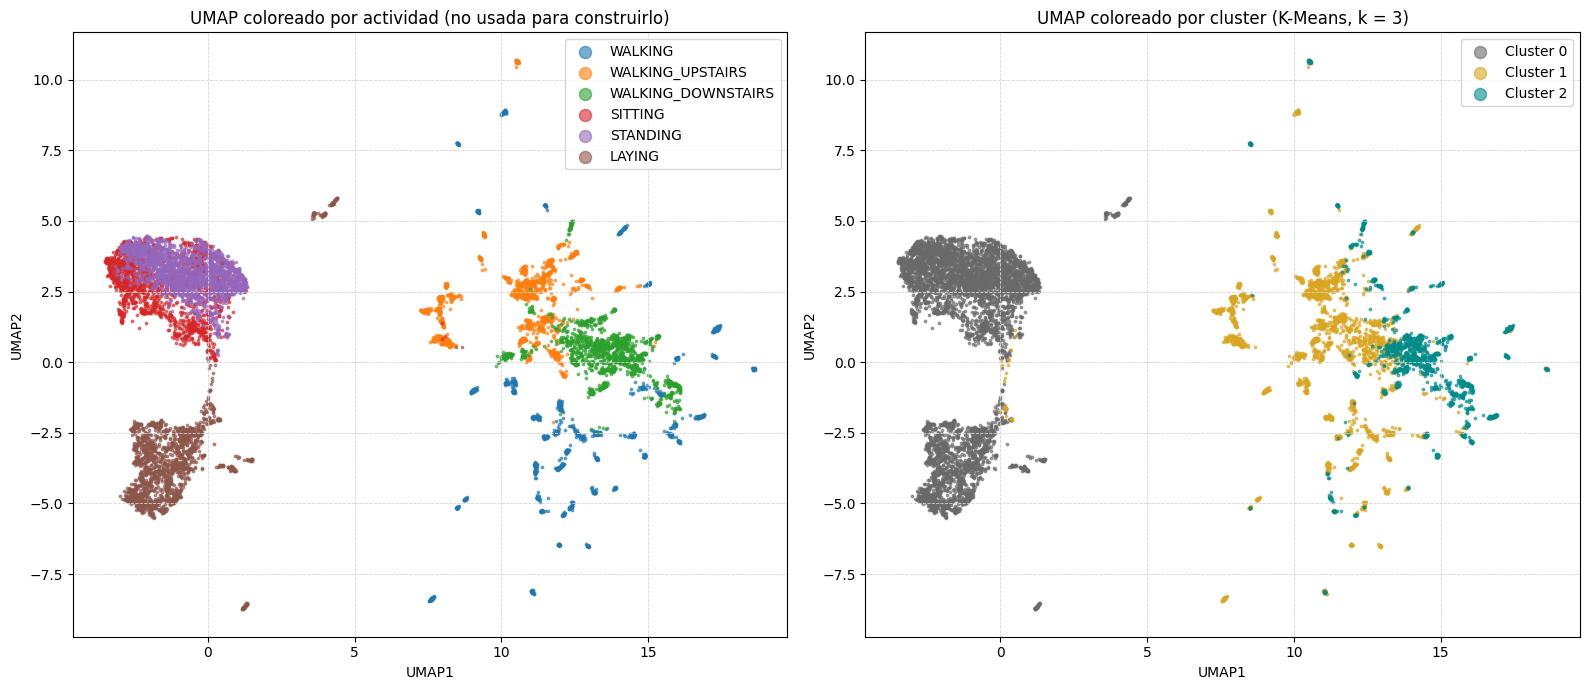

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for a in ORDEN_ACTIVIDADES:
    m = (actividad == a).values
    axes[0].scatter(X_umap[m, 0], X_umap[m, 1], s=3, alpha=0.6, color=COLORES_ACTIVIDADES[a], label=a)
axes[0].set_title("UMAP coloreado por actividad (no usada para construirlo)")
axes[0].legend(markerscale=5)

for k in range(K):
    m = clusters == k
    axes[1].scatter(X_umap[m, 0], X_umap[m, 1], s=3, alpha=0.6, color=COLORES_CLUSTERS[k], label=f"Cluster {k}")
axes[1].set_title(f"UMAP coloreado por cluster (K-Means, k = {K})")
axes[1].legend(markerscale=5)

for ax in axes:
    ax.set_xlabel("UMAP1")
    ax.set_ylabel("UMAP2")
    ax.grid(color="lightgray", linestyle="--", linewidth=0.6)
plt.tight_layout()
plt.show()

En UMAP se ven tres regiones bien separadas:
- Una con las actividades en movimiento, donde bajar y subir escaleras forman zonas más densas y caminar aparece partido en muchas islas chicas, algunas bastante alejadas del resto.
- Una con sentado y parado juntos. Hay cierto gradiente entre los dos (cada uno tiende a ocupar un lado de la región), pero sin una frontera clara, igual que en el clustering.
- Una región propia para acostado, separada de las otras dos.

Comparando con el clustering, el cluster 0 ocupa las dos regiones de reposo y los clusters 1 y 2 se reparten la de movimiento (el 2 se concentra en la zona de bajar escaleras y el 1, en la de subir escaleras). La gran diferencia es acostado: UMAP lo separa claramente y el clustering sobre PCA no. Tiene sentido, porque PCA prioriza la varianza global, que está dominada por el movimiento, mientras que UMAP conserva los vecindarios, y los vecinos más cercanos de una ventana de acostado son casi siempre otras ventanas de acostado.

También aparecen algunos puntos y grupos aislados, como una isla chica de acostado separada del resto de su región, que podrían corresponder a posturas o formas de llevar el teléfono poco habituales.

Un detalle: las coordenadas de UMAP no significan nada por sí solas, solo importan las distancias relativas entre puntos. Por eso, según el entorno donde se ejecute, el gráfico puede salir espejado o rotado sin que cambie la estructura.

Nos quedaba una pregunta: ¿qué son las islas de caminar? Para verlo, coloreamos las ventanas de caminar según la persona.

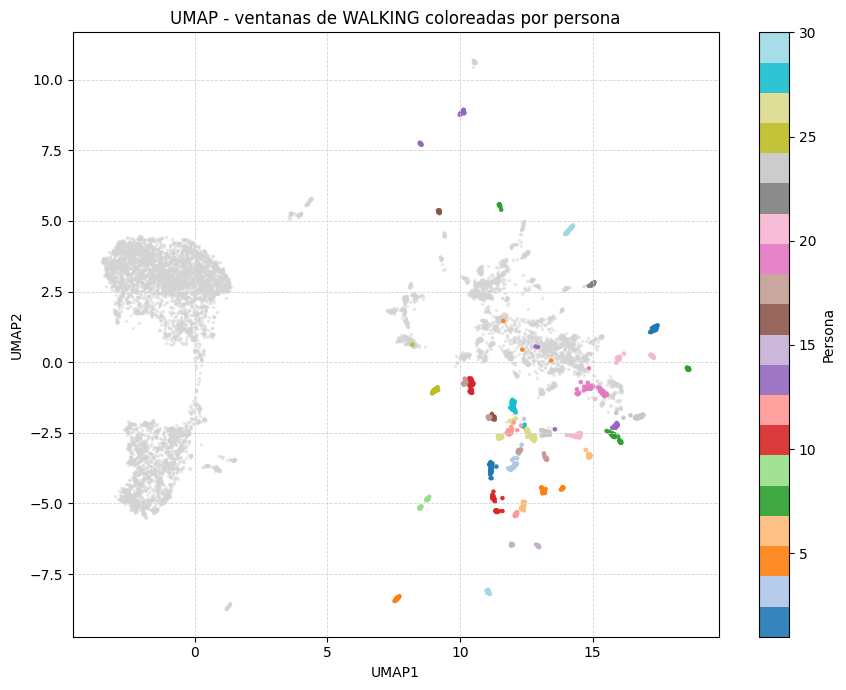

In [35]:
plt.figure(figsize=(9, 7))
plt.scatter(X_umap[:, 0], X_umap[:, 1], s=2, color="lightgray", alpha=0.4)
caminar = (actividad == "WALKING").values
scatter = plt.scatter(X_umap[caminar, 0], X_umap[caminar, 1], s=5, c=sujeto[caminar], cmap="tab20", alpha=0.9)
plt.colorbar(scatter, label="Persona")
plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.title("UMAP - ventanas de WALKING coloreadas por persona")
plt.grid(color="lightgray", linestyle="--", linewidth=0.6)
plt.tight_layout()
plt.show()

Cada isla tiene prácticamente un solo color, así que cada isla corresponde a una persona (algunos colores se repiten porque la paleta tiene 20 colores y hay 30 personas). Cada persona tiene una forma de caminar propia y reconocible, lo que refuerza el efecto de la persona que ya habíamos visto en el clustering (hipótesis 4). En las escaleras esto no se ve tan claro, probablemente porque el escalón condiciona más el movimiento.

Como conclusión de esta parte, UMAP confirma la estructura que encontró el clustering (movimiento vs. reposo y la mezcla entre actividades parecidas) y además muestra dos cosas que en PCA quedaban escondidas: la separación de acostado y las diferencias entre personas al caminar.

### Bonus: HDBSCAN sobre la proyección de UMAP

Esto no lo pide la consigna, pero como UMAP separaba claramente a acostado, nos dio curiosidad ver qué pasa si aplicamos HDBSCAN sobre su proyección en lugar de sobre PCA. Hay que tomarlo como algo exploratorio: UMAP deforma las densidades y las distancias, así que los grupos que aparecen sobre su proyección pueden depender de cómo arma el gráfico y no solo de la estructura real de los datos.

Igual que antes, probamos varios valores de `min_cluster_size`.

In [36]:
resultados_umap = {}
filas = []

for min_cluster_size in [25, 50, 75, 100, 150, 200, 500, 1000, 2000]:
    etiquetas = ordenar_por_tamanio(HDBSCAN(min_cluster_size=min_cluster_size).fit_predict(X_umap))
    resultados_umap[min_cluster_size] = etiquetas

    filas.append({
        "min_cluster_size": min_cluster_size,
        "clusters": etiquetas.max() + 1,
        "% ruido": round((etiquetas == -1).mean() * 100, 1),
    })

pd.DataFrame(filas)

,min_cluster_size,clusters,% ruido
0,25,64,6.1
1,50,32,13.1
2,75,12,17.8
3,100,8,11.9
4,150,3,2.8
5,200,3,3.4
6,500,3,5.2
7,1000,3,7.1
8,2000,2,15.8


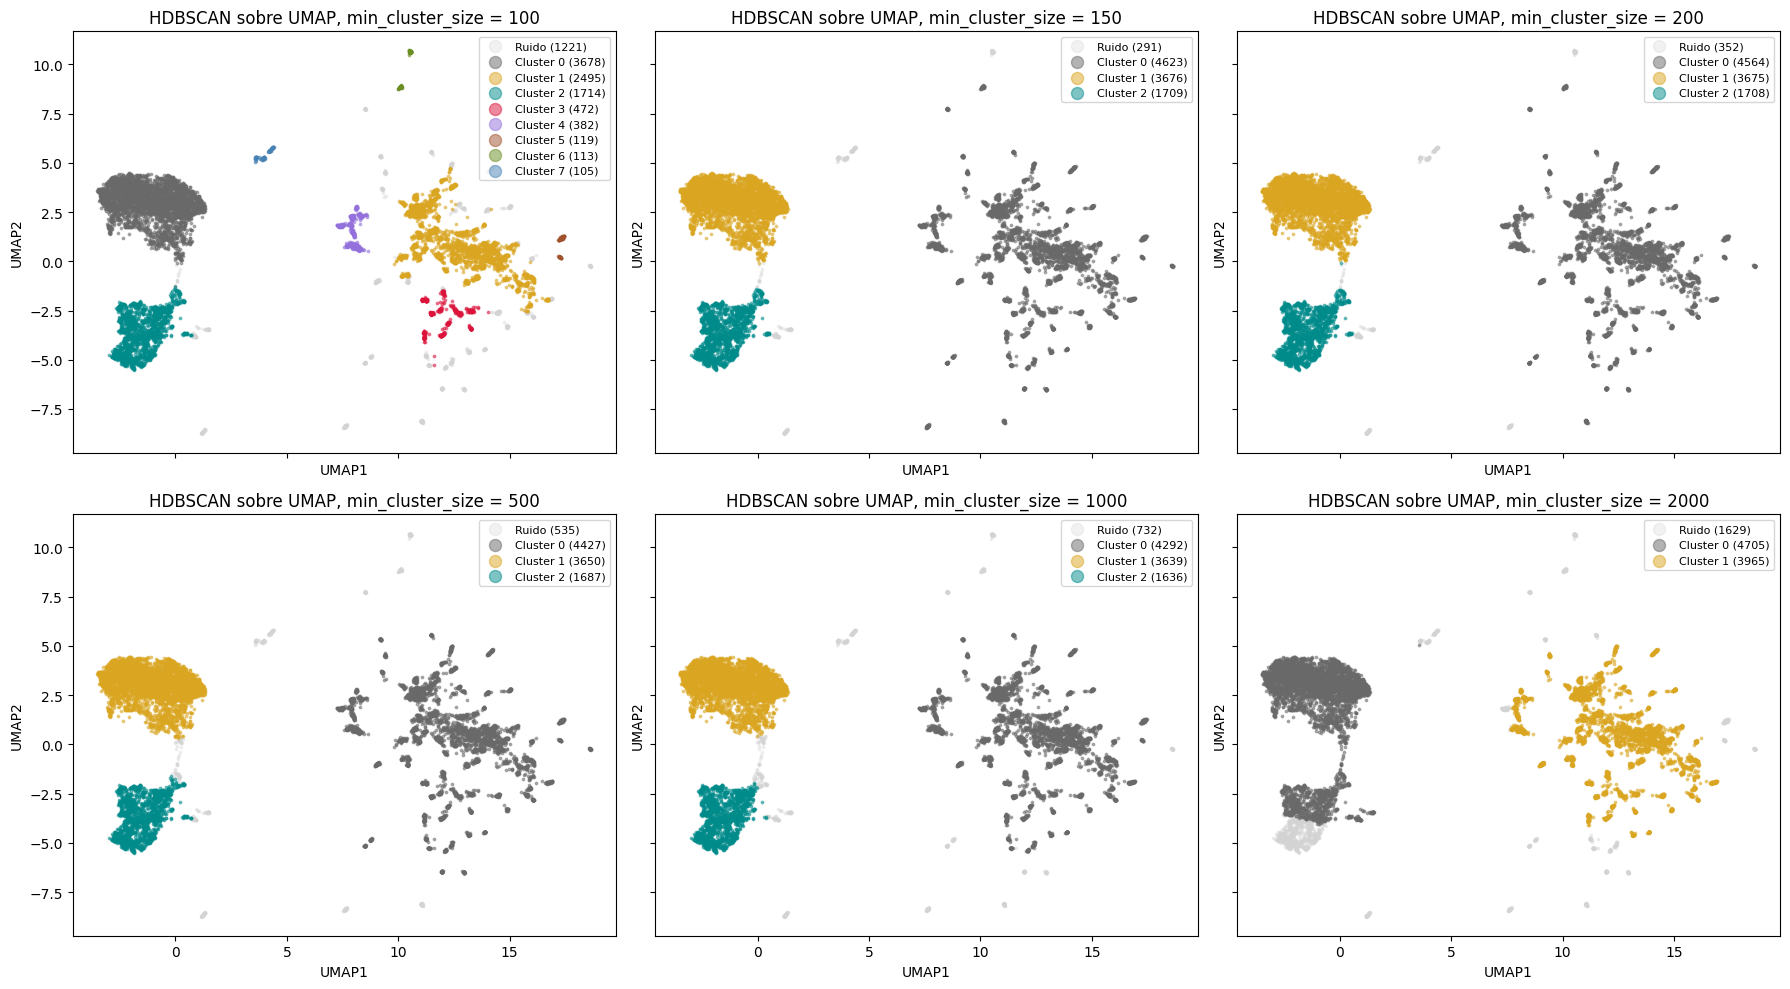

In [37]:
# Graficamos desde min_cluster_size = 100 (con valores más chicos aparecen decenas de clusters)
graficables = [m for m in resultados_umap if m >= 100]

fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharex=True, sharey=True)
for ax, min_cluster_size in zip(axes.flatten(), graficables):
    graficar_clusters(ax, resultados_umap[min_cluster_size], f"HDBSCAN sobre UMAP, min_cluster_size = {min_cluster_size}",
                      coords=X_umap, ejes=("UMAP1", "UMAP2"))
plt.tight_layout()
plt.show()

Al variar `min_cluster_size` el resultado cambia bastante:
- Con valores chicos (25 a 75) aparecen muchos clusters chicos, entre 64 y 12 respectivamente. En buena parte son las islas de caminar que, como vimos, corresponden a personas.
- Con 100 todavía aparecen 8 clusters.
- Entre 150 y 1.000 el resultado se estabiliza en 3 clusters, con poco ruido (entre 2.8% y 7.1%).
- Con 2.000 vuelve a 2 clusters: acostado tiene unas 1.900 ventanas, así que ya no llega al tamaño mínimo para formar su propio cluster y gran parte de sus ventanas pasa a ser ruido.

Nos quedamos con `min_cluster_size = 150`, que además de dar 3 clusters es el que deja menos ruido de todos los valores probados. Veamos qué actividades caen en cada cluster.

In [38]:
etiquetas_umap = resultados_umap[150]
pd.crosstab(actividad, pd.Series(etiquetas_umap, name="Cluster (-1 = ruido)")).reindex(ORDEN_ACTIVIDADES)

Cluster (-1 = ruido),-1,0,1,2
Activity,,,,
WALKING,0,1722,0,0
WALKING_UPSTAIRS,54,1490,0,0
WALKING_DOWNSTAIRS,0,1406,0,0
SITTING,0,3,1765,9
STANDING,0,0,1906,0
LAYING,237,2,5,1700


Los 3 clusters coinciden con las tres regiones que veíamos en el gráfico de UMAP: uno con las tres actividades en movimiento, otro con sentado y parado juntos, y un tercero con acostado. Acostado queda separado en su gran mayoría: 1.700 de sus 1.944 ventanas (87%) forman un cluster propio, y casi todas las demás (237) quedan como ruido. Probablemente porque pertenecen a las islas chicas de acostado que se veían alejadas del resto de su región. En total, solo el 2,8% de los datos queda sin asignar.

Es una solución distinta a la de K-Means sobre PCA, aunque las dos tienen 3 clusters. Las dos separan movimiento y reposo, pero la tercera división cambia: con PCA se parte el movimiento según su intensidad, mientras que con UMAP se separa acostado. Cada representación resalta una señal diferente: PCA, la que más varianza aporta (el movimiento), y UMAP, la que mejor se refleja en los vecindarios (la orientación de acostado). Sentado y parado, en cambio, siguen juntos con los dos enfoques.

## 5. Conclusiones

**Sobre las técnicas**
- PCA resumió muy bien los datos: con 42 de las 561 variables conservamos el 85% de la varianza, y la primera componente, que representa la intensidad del movimiento, explica sola el 51%. La contracara es que, al priorizar la varianza, deja en segundo plano la orientación del teléfono, que tiene muchas menos variables.
- Elegimos K-Means con k = 3. Según la silueta, la mejor partición es k = 2 (movimiento vs. reposo), pero k = 3 agrega una división interpretable del movimiento según su intensidad. Es muy estable y tiene la mejor silueta entre las soluciones con más de 2 clusters. El jerárquico encontró prácticamente la misma estructura, y su dendrograma mostró que la división en 2 grupos es mucho más fuerte que cualquier otra. HDBSCAN confirmó esa división, pero dejó como ruido gran parte de la nube de movimiento, que es un continuo y no un conjunto de grupos densos.
- UMAP complementó bien a PCA: al conservar los vecindarios, mostró cosas que PCA dejaba en segundo plano, como la separación de acostado y las diferencias entre personas al caminar.
- La representación sobre la que se agrupa importa tanto como el algoritmo. Con HDBSCAN sobre UMAP (el bonus) también aparecen 3 clusters, pero la tercera división es acostado y no la intensidad del movimiento: cada representación resalta una señal distinta de los datos.

**Sobre las hipótesis**
1. Movimiento vs. reposo: se confirma. Es la estructura dominante y se separa casi sin errores.
2. Acostado distinguible por la orientación: se confirma solo en parte. La diferencia existe, pero el clustering sobre PCA no la captura. En UMAP, en cambio, aparece como una región propia, y HDBSCAN sobre esa proyección separa el 87% de sus ventanas.
3. Sentado y parado difíciles de separar: se confirma. No se separan con ninguna técnica.
4. Mezcla entre las formas de caminar y efecto de la persona: se confirma. Las actividades en movimiento se reparten entre los clusters, varias personas caen casi enteras en un mismo cluster, y en UMAP cada persona forma su propia isla al caminar.

**Conclusión general.** Sin usar las etiquetas, los datos se organizan primero según si la persona se mueve o no, y después según cuánto se mueve. Las actividades aparecen como consecuencia de esas dos señales, junto con un efecto bastante fuerte de quién hace el movimiento. Si quisiéramos entrenar un clasificador con estos datos, esto nos dice de antemano qué distinciones van a ser fáciles y cuáles difíciles.